In [1]:
# ===============================================================
# IMPORTS
# ===============================================================
# Standard library imports
import os
import re
import sys
import time
import pickle
import random
from pathlib import Path
from glob import glob
from collections import Counter, defaultdict
from concurrent.futures import ProcessPoolExecutor, as_completed

# Third-party scientific computing
import numpy as np
import pandas as pd

# Image processing
import imageio.v2 as imageio
import cv2
from skimage import (
    exposure, measure, filters, segmentation, 
    morphology, data, color, img_as_float
)
from skimage.feature import peak_local_max, blob_dog
from skimage.measure import regionprops
from skimage.segmentation import watershed, mark_boundaries
from skimage.filters import sobel
import skimage.filters

# Scientific computing
from scipy import ndimage as ndi
from scipy.spatial.distance import cdist, pdist
from scipy.spatial import distance_matrix, Delaunay
from scipy.ndimage import generate_binary_structure, binary_dilation
from scipy.stats import qmc

# Visualization
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from tqdm import tqdm, trange

# Cellpose (nucleus segmentation)
from cellpose import models, core, io, plot, train, metrics

# Project-specific modules
from config_loader import config as Config
from watershed_configurator import WatershedConfigurator
from nucleus_worker_Visualization import (
    process_single_nucleus,
    compute_adaptive_background_texture_nucleus_fallback,
    detect_foci_single_channel 
)
from parameter_space_generator import ParameterSpaceGenerator
from adaptive_parameter_selector import AdaptiveParameterSelector

In [ ]:
# ===============================================================
# DISPLAY CURRENT CONFIGURATION
# ===============================================================
# Print all loaded configuration settings to console
Config.print_config()

# ===============================================================
# CHECK FOLDER PATH
# ===============================================================
# Extract folder path from configuration
folder_path = Config.FOLDER_PATH

# Verify folder exists on disk
if os.path.isdir(folder_path):
    print("✅ Folder path exists")
    
    # List all contents in the folder
    dir_contents = os.listdir(folder_path)
    
    # Check if folder is empty
    if len(dir_contents) == 0:
        print("⚠️  Empty directory")
    else:
        # Show how many items are in the folder
        print(f"✅ Found {len(dir_contents)} files/folders")
else:
    # Folder doesn't exist - terminate program
    print("❌ Folder path not found")
    sys.exit(1)  # Exit with error code 1


CURRENT CONFIGURATION
data:
  folder_path: Y:\Group Members\Valentin Aubry\01_Data\Test_Data_Andreas_hard
parameter_space:
  generate_new: True
  tritc_path: Y:\Group Members\Valentin Aubry\01_Data\Parameters\Complete_KDE\TRITC_parameter_space
  fitc_path: Y:\Group Members\Valentin Aubry\01_Data\Parameters\Complete_KDE\FITC_parameter_space
  n_samples: 256
  n_sobol_samples: 65536
adaptive_parameters:
  enabled: True
  n_calibration_images: 1
  n_calibration_params: 256
  n_production_params: 1
  calibration_save_path: Y:\Group Members\Valentin Aubry\01_Data\Parameters\Complete_KDE\calibration_results.pkl
  recalibrate: False
  load_reduced_parameters: False
  reduced_tritc_path: Y:\Group Members\Valentin Aubry\01_Data\Parameters\Complete_KDE\reduced_params_TRITC.pkl
  reduced_fitc_path: Y:\Group Members\Valentin Aubry\01_Data\Parameters\Complete_KDE\reduced_params_FITC.pkl
  randomize_calibration_order: True
  random_seed: 42
watershed:
  mode: manual_preset
  n_images_for_threshold:

In [ ]:
# ===============================================================
# DATA LOADING
# ===============================================================
# Use glob to find all image files matching each channel pattern
# Expects files named: *_<CHANNEL>_SEM.tif or *_DAPI_SEM_seg.npy

Cy5_data = glob(os.path.join(folder_path, '*Cy5 SEM.tif'))
DAPI_data = glob(os.path.join(folder_path, '*DAPI SEM.tif'))
DAPI_mask_data = glob(os.path.join(folder_path, '*DAPI SEM_seg.npy'))  # Segmentation masks
FITC_data = glob(os.path.join(folder_path, '*FITC SEM.tif'))
TRITC_data = glob(os.path.join(folder_path, '*TRITC SEM.tif'))

# Sort alphabetically to ensure channels match by position
# Critical: Each index must correspond to the same image position across all channels
Cy5_data.sort()
DAPI_data.sort()
DAPI_mask_data.sort()
FITC_data.sort()
TRITC_data.sort()

print(f"\n📊 Loaded image paths:")
print(f"   Total positions: {len(DAPI_data)}")

# ===============================================================
# IMAGE ORDER AND RESUME LOGIC
# ===============================================================

# Create indices for all images (0 to N-1)
all_indices = list(range(len(DAPI_data)))
total_images = len(DAPI_data)

# Initialize random number generators with seed from config
random_seed = Config.RANDOM_SEED
if random_seed is not None:
    # Set seed for both random and numpy.random for consistency
    random.seed(random_seed)
    np.random.seed(random_seed)
    print(f"\n🎲 Using fixed random seed: {random_seed}")
    print(f"   (Ensures reproducible image order for calibration AND resume)")
else:
    # No seed = different random order each run (breaks resume)
    print(f"\n⚠️  WARNING: No random seed set - order will be different each run!")
    print(f"   💡 Set adaptive_parameters.random_seed in config.yaml for:")
    print(f"      - Reproducible calibration")
    print(f"      - Resume capability")

# Randomly shuffle image order (or keep sequential)
if Config.RANDOMIZE_CALIBRATION_ORDER:
    random.shuffle(all_indices)  # In-place shuffle of index list
    print(f"✅ Randomized image order")
else:
    print(f"📋 Using sequential image order")

# Get resume settings from config
resume_from = Config.RESUME_FROM_IMAGE  # Skip first N images
max_images = Config.MAX_IMAGES  # Process at most this many images

# Calculate which images to process this run
start_idx = resume_from
# If max_images is set, cap at (resume_from + max_images), otherwise process all remaining
end_idx = min(resume_from + max_images, total_images) if max_images else total_images

# Extract the slice of indices to process
processing_indices = all_indices[start_idx:end_idx]

# Print summary of what will be processed
print(f"\n📊 IMAGE PROCESSING PLAN:")
print(f"   Total images in dataset: {total_images}")
print(f"   Starting from image: {start_idx + 1}")  # +1 for human-readable (1-based)
print(f"   Ending at image: {end_idx}")
print(f"   Images to process this run: {len(processing_indices)}")

# Show resume status if applicable
if resume_from > 0:
    print(f"   🔄 RESUMING from image {start_idx + 1} (skipped first {resume_from})")

# Show continuation instructions if not processing all images
if max_images is not None and end_idx < total_images:
    print(f"   ⏸️  Processing limited to {max_images} images")
    print(f"   💡 To continue: set resume_from_image: {end_idx} in config.yaml")

# Display list of all loaded filenames (just first part for brevity)
print(f"\n📁 Loaded files:")
for i in range(len(DAPI_data)):
    # Split on '--' and show only experiment name (first part)
    print(f"  [{i}] {os.path.basename(DAPI_data[i]).split('--')[0]}")

🎲 Using fixed random seed: 42
   (Ensures reproducible image order for calibration AND resume)
✅ Randomized image order

📊 IMAGE PROCESSING PLAN:
   Total images in dataset: 15
   Starting from image: 1
   Ending at image: 3
   Images to process this run: 3
   ⏸️  Processing limited to 3 images
   💡 To continue: set resume_from_image: 3 in config.yaml
ATR1_24h--W00032--P00015--Z00000--T00000--Cy5 SEM.tif
ATR1_24h--W00032--P00015--Z00000--T00000--DAPI SEM.tif
ATR1_24h--W00032--P00015--Z00000--T00000--DAPI SEM_seg.npy
ATR1_24h--W00032--P00015--Z00000--T00000--FITC SEM.tif
ATR1_24h--W00032--P00015--Z00000--T00000--TRITC SEM.tif
ATR1_8h--W00029--P00035--Z00000--T00000--Cy5 SEM.tif
ATR1_8h--W00029--P00035--Z00000--T00000--DAPI SEM.tif
ATR1_8h--W00029--P00035--Z00000--T00000--DAPI SEM_seg.npy
ATR1_8h--W00029--P00035--Z00000--T00000--FITC SEM.tif
ATR1_8h--W00029--P00035--Z00000--T00000--TRITC SEM.tif
ATR1_UT--W00026--P00005--Z00000--T00000--Cy5 SEM.tif
ATR1_UT--W00026--P00005--Z00000--T00000-

In [ ]:
# ===============================================================
# HELPER FUNCTIONS
# ===============================================================
# Utility functions used throughout the pipeline.
# These are defined here (not inside if __name__ == '__main__':) 
# so they can be imported by other modules if needed.
# ===============================================================


def farthest_point_sampling(points, n_samples):
    """
    Select maximally spread subset of points using greedy farthest-point algorithm.
    
    This ensures even spatial coverage across parameter space by iteratively
    selecting points that are maximally distant from already-selected points.
    Similar to Poisson-disk sampling but faster and deterministic.
    
    Algorithm:
    ----------
    1. Start with one random point
    2. For each subsequent point:
       - Calculate distance to nearest selected point for all candidates
       - Select the candidate with maximum distance (farthest from selected set)
       - Add to selected set and update distances
    3. Repeat until n_samples points selected
    
    Parameters:
    -----------
    points : ndarray, shape (N, D)
        Full set of candidate points (e.g., N=10000 Sobol samples in D=3 dimensions)
        Typically these are scaled parameter combinations inside a valid hull
    n_samples : int
        Number of points to select (e.g., 256)
        Must be less than or equal to total number of candidate points
    
    Returns:
    --------
    ndarray, shape (n_samples, D)
        Selected subset of points maximally spread apart
        These points will have good coverage of the parameter space
    
    Raises:
    -------
    ValueError : If n_samples exceeds number of available points
    
    Example:
    --------
    >>> candidates = np.random.rand(10000, 3)  # 10k random 3D points
    >>> selected = farthest_point_sampling(candidates, 256)  # Pick 256 spread out
    >>> selected.shape
    (256, 3)
    """
    n = len(points)
    
    # Validate input
    if n_samples > n:
        raise ValueError(
            f"Cannot select {n_samples} samples from only {n} available points. "
            f"Either reduce n_samples or increase the candidate pool size."
        )
    
    # ================================================================
    # STEP 1: Initialize with one random starting point
    # ================================================================
    # Pick a random point from the candidate pool to be the first selected point.
    # This becomes the "seed" - all subsequent selections are based on distance from this.
    # np.random.randint(0, n) returns a random integer in range [0, n-1]
    selected_idx = [np.random.randint(0, n)]
    
    # ================================================================
    # STEP 2: Calculate initial distances to the first selected point
    # ================================================================
    # For every candidate point, calculate its Euclidean distance to the first selected point.
    # 
    # How this works:
    # - points: shape (N, D) - all N candidate points in D-dimensional space
    # - points[selected_idx[0]]: shape (D,) - the first selected point
    # - points - points[selected_idx[0]]: broadcasting subtracts the selected point from all points
    #   Result: shape (N, D) - vectors from selected point to each candidate
    # - np.linalg.norm(..., axis=1): calculate length of each vector (Euclidean distance)
    #   Result: shape (N,) - one distance value per candidate point
    # 
    # At this stage, dists[i] = distance from point i to the first selected point
    dists = np.linalg.norm(points - points[selected_idx[0]], axis=1)
    
    # ================================================================
    # STEP 3: Iteratively select the farthest point from the selected set
    # ================================================================
    # We need to select (n_samples - 1) more points (already have 1)
    for _ in range(1, n_samples):
        # --------------------------------------------------------
        # 3a. Find the point that is farthest from ANY selected point
        # --------------------------------------------------------
        # np.argmax(dists) returns the index of the maximum value in dists
        # Since dists[i] stores "distance to NEAREST selected point",
        # the point with maximum dists[i] is in the "largest empty region"
        # (it's the point that's farthest from the selected cluster)
        next_idx = np.argmax(dists)
        selected_idx.append(next_idx)
        
        # --------------------------------------------------------
        # 3b. Update the distance array to reflect the new selected point
        # --------------------------------------------------------
        # Now that we've added a new point to the selected set, we need to update
        # each candidate's "distance to nearest selected point"
        #
        # Calculate distance from ALL candidates to the newly selected point:
        # - points - points[next_idx]: vectors from new point to all candidates
        # - np.linalg.norm(..., axis=1): distance from new point to each candidate
        # Result: new_dists[i] = distance from point i to the newly selected point
        new_dists = np.linalg.norm(points - points[next_idx], axis=1)
        
        # Update the distance array:
        # - dists[i]: current "distance to nearest selected point" (before adding new point)
        # - new_dists[i]: distance to the newly added point
        # - np.minimum(dists, new_dists): element-wise minimum
        # 
        # After this operation, dists[i] stores the MINIMUM of:
        #   1. Previous nearest distance (to any of the earlier selected points)
        #   2. Distance to the newly added point
        # 
        # This ensures dists[i] ALWAYS represents "distance to the NEAREST selected point"
        # accounting for ALL selected points so far
        dists = np.minimum(dists, new_dists)
        
        # Now the loop repeats: argmax(dists) will find the next point in the
        # largest remaining empty region, and we continue until n_samples selected
    
    # Return the selected subset
    return points[selected_idx]


def in_hull(p, delaunay_obj):
    """
    Test if points lie inside a convex hull defined by Delaunay triangulation.
    
    A convex hull is the smallest convex shape that contains all training points.
    Think of it like a rubber band stretched around points in 3D space with no concave regions.
    We use this to filter out parameter combinations that lie outside the
    "known good" region defined during parameter space generation.
    
    How it works:
    -------------
    Scipy's Delaunay triangulation divides the convex hull into simplices
    (triangles in 2D, tetrahedra in 3D(like a chemical C-only structure)). The find_simplex() method returns:
    - Index >= 0: Point is inside a simplex (inside hull)
    - Index = -1: Point is outside all simplices (outside hull)
    
    Parameters:
    -----------
    p : ndarray, shape (N, 3)
        Points to test in 3D parameter space
        Each row is one parameter combination: [bright_pct, contrast_thresh, percentile_val]
    delaunay_obj : scipy.spatial.Delaunay
        Delaunay triangulation object representing the convex hull
        Created during parameter space generation from validated parameters
    
    Returns:
    --------
    ndarray, shape (N,), dtype bool
        Boolean mask where True = point inside hull, False = outside hull
        Use this to filter parameter arrays: valid_params = all_params[in_hull(all_params, hull)]
    
    Example:
    --------
    >>> # Generate 1000 test points
    >>> test_points = np.random.rand(1000, 3) * 100
    >>> # Load pre-computed hull
    >>> with open('valid_hull.pkl', 'rb') as f:
    ...     hull = pickle.load(f)
    >>> # Filter to points inside hull
    >>> mask = in_hull(test_points, hull)
    >>> valid_points = test_points[mask]
    >>> print(f"{mask.sum()} points inside hull")
    """
    # find_simplex returns -1 for points outside hull, >= 0 for inside
    # Convert to boolean: True if inside, False if outside
    return delaunay_obj.find_simplex(p) >= 0


def generate_parameter_space_for_channel(
    channel_name,
    channel_data_paths,
    mask_data_paths,
    output_base_dir,
    param_ranges=None,
    num_nuclei=10,
    coverage_percentile=85
):
    """
    Generate and validate parameter space for a fluorescence channel.
    
    This is an INTERACTIVE function that requires user input to annotate nuclei
    with known foci counts. The system then tests thousands of parameter combinations
    and keeps only those that correctly detect the annotated counts.
    
    Workflow:
    ---------
    1. Load first image and display nuclei for selection
    2. User clicks on nuclei and enters known foci count for each
    3. System tests all parameter combinations on annotated nuclei
    4. Keep only parameters that give correct counts for ALL nuclei
    5. Generate KDE-based parameter space from valid combinations
    6. Save results (hull, bounds, valid points) for future use
    
    Why this matters:
    -----------------
    Different imaging conditions (microscope, staining, cell type) require
    different detection parameters. This process finds the "sweet spot" of
    parameters that work reliably for your specific data.
    
    Parameters:
    -----------
    channel_name : str
        Channel identifier (e.g., 'TRITC', 'FITC', 'Cy5')
        Used for display and naming output files
    channel_data_paths : list of str
        Paths to all channel image files
        First image is used for annotation, others are for validation
    mask_data_paths : list of str
        Paths to nucleus segmentation masks (from Cellpose)
        Must match order of channel_data_paths
    output_base_dir : str
        Base directory where parameter space will be saved
        Creates subdirectory: {output_base_dir}/{channel_name}_parameter_space/
    param_ranges : dict, optional
        Custom parameter ranges. Keys must be:
        - 'bright_pct': (min, max) for background percentile
        - 'contrast_thresh': (min, max) for contrast threshold
        - 'percentile_val': (min, max) for global percentile
        If None, uses defaults: bright_pct=(0,100), contrast_thresh=(1,10), percentile_val=(0,100)
    num_nuclei : int, default=10
        Number of nuclei to manually annotate
        More nuclei = more robust but more time-consuming
        Recommended: 2-3 for quick setup, 10+ for production
    coverage_percentile : float, default=85
        KDE coverage percentile for parameter space generation
        Higher = more conservative (larger valid region)
        Typical values: 80-90%
    
    Returns:
    --------
    ParameterSpaceGenerator
        Fitted generator object containing validated parameters
        Saved to disk automatically, so return value mainly for inspection
    
    Raises:
    -------
    ValueError : If no valid parameter intersection found
    FileNotFoundError : If image/mask files don't exist
    
    Output Files:
    -------------
    Creates directory: {output_base_dir}/{channel_name}_parameter_space/
    Contains:
    - valid_parameter_hull.pkl: Delaunay triangulation of valid region
    - parameter_bounds.npz: Min/max bounds for each parameter
    - valid_points.npy: All validated parameter combinations
    - kde_metadata.pkl: KDE model and generation metadata
    
    Example Usage:
    --------------
    >>> tritc_paths = glob('data/*TRITC*.tif')
    >>> mask_paths = glob('data/*_seg.npy')
    >>> generator = generate_parameter_space_for_channel(
    ...     channel_name='TRITC',
    ...     channel_data_paths=tritc_paths,
    ...     mask_data_paths=mask_paths,
    ...     output_base_dir='parameters/',
    ...     num_nuclei=5
    ... )
    """
    # Print header
    print("\n" + "="*70)
    print(f"PARAMETER SPACE GENERATION FOR {channel_name.upper()} CHANNEL")
    print("="*70)
    
    # ================================================================
    # STEP 1: Load first image for annotation
    # ================================================================
    print(f"\n1️⃣ Loading {channel_name} image and mask...")
    
    # Load channel image (fluorescence)
    channel_pic = imageio.imread(channel_data_paths[0])
    
    # Load segmentation mask (nucleus boundaries from Cellpose)
    mask_pic = np.load(mask_data_paths[0], allow_pickle=True)
    
    print(f"   ✓ Loaded: {os.path.basename(channel_data_paths[0])}")
    print(f"   Image shape: {channel_pic.shape}")
    print(f"   Nuclei found: {len(np.unique(mask_pic)) - 1}")  # -1 for background
    
    # ================================================================
    # STEP 2: Define parameter ranges
    # ================================================================
    # These define the search space for valid parameters
    if param_ranges is None:
        param_ranges = {
            'bright_pct': (0, 100),      # Background brightness percentile (0-100%)
            'contrast_thresh': (1, 10),   # How much brighter than background (1x-10x)
            'percentile_val': (0, 100)    # Global minimum brightness cutoff (0-100%)
        }
    
    print(f"\n2️⃣ Parameter ranges to explore:")
    for param, (min_val, max_val) in param_ranges.items():
        print(f"   {param}: {min_val} - {max_val}")
    
    # ================================================================
    # STEP 3: Create generator and initialize
    # ================================================================
    print(f"\n3️⃣ Creating parameter space generator...")
    
    # Resolution = number of values to test per parameter
    # resolution=20 means 20×20×20 = 8000 combinations to test
    generator = ParameterSpaceGenerator(param_ranges, resolution=20)
    print(f"   Will test {20**3} parameter combinations")
    
    # ================================================================
    # STEP 4: Interactive nucleus selection and annotation
    # ================================================================
    print(f"\n4️⃣ STEP 1: Interactive nucleus selection")
    print(f"   Goal: Select {num_nuclei} nuclei with known foci counts")
    print(f"   You will:")
    print(f"   - View all nuclei in the image")
    print(f"   - Select nuclei by clicking or entering IDs")
    print(f"   - Count foci manually and enter the count")
    print(f"   - System will find parameters that match your counts")
    
    # This is an INTERACTIVE function - opens matplotlib windows
    # User clicks nuclei and enters counts
    selected = generator.interactive_nucleus_selection(
        masks=mask_pic,
        channel_image=channel_pic,
        num_nuclei=num_nuclei,
        mask_data_paths=mask_data_paths,
        channel_data_paths=channel_data_paths
    )
    
    print(f"   ✓ Selected {len(selected)} nuclei with known foci counts")
    
    # ================================================================
    # STEP 5: Grid search - test all parameter combinations
    # ================================================================
    print(f"\n5️⃣ STEP 2: Running grid search with foci detection...")
    print(f"   Testing all {20**3} combinations on {len(selected)} annotated nuclei")
    print(f"   This may take a few minutes...")
    
    # For each nucleus, test all parameter combinations
    # Records which parameters correctly detected the annotated count
    generator.generate_grid_search(mask_pic, channel_pic, channel_pic)
    
    print(f"   ✓ Grid search complete")
    
    # ================================================================
    # STEP 6: Find parameter intersection
    # ================================================================
    print(f"\n6️⃣ STEP 3: Finding valid parameter intersection...")
    print(f"   Looking for parameters that work for ALL {len(selected)} nuclei")
    
    # Find parameters that gave correct counts for ALL annotated nuclei
    # This is the intersection of valid parameters across all nuclei
    valid_params = generator.find_valid_intersection()
    
    if valid_params is not None and len(valid_params) > 0:
        print(f"   ✓ Found {len(valid_params)} valid parameter combinations")
        print(f"   These parameters correctly detected foci in all annotated nuclei")
    else:
        print(f"   ⚠️ WARNING: No valid intersection found!")
        print(f"   No single parameter set worked for all nuclei")
        print(f"\n   Possible solutions:")
        print(f"   - Adjust parameter ranges (widen the search space)")
        print(f"   - Select different nuclei (avoid edge cases)")
        print(f"   - Annotate more nuclei (increases chance of overlap)")
        print(f"   - Check if foci counts were entered correctly")
        return generator
    
    # ================================================================
    # STEP 7: Generate KDE parameter space
    # ================================================================
    print(f"\n7️⃣ STEP 4: Generating KDE parameter space...")
    print(f"   Creating smooth probability distribution around valid parameters")
    
    # KDE (Kernel Density Estimation) creates a smooth "blob" around valid points
    # Coverage percentile determines how much of the blob to include
    # 85% = include central 85% of probability mass (excludes outliers)
    generator.generate_kde_parameter_space(coverage_percentile=coverage_percentile)
    
    print(f"   ✓ KDE space generated with {coverage_percentile}% coverage")
    print(f"   Parameter space is now ready for sampling")
    
    # ================================================================
    # STEP 8: Save results
    # ================================================================
    print(f"\n8️⃣ STEP 5: Saving parameter space...")
    
    # Create output directory
    output_dir = os.path.join(output_base_dir, f"{channel_name}_parameter_space")
    os.makedirs(output_dir, exist_ok=True)
    
    # Save all components (hull, bounds, valid points, KDE metadata)
    generator.save_complete(output_dir)
    
    print(f"   ✓ Saved to: {output_dir}")
    print(f"   Files created:")
    print(f"     - valid_parameter_hull.pkl (Delaunay triangulation)")
    print(f"     - parameter_bounds.npz (min/max for each parameter)")
    print(f"     - valid_points.npy (all validated combinations)")
    print(f"     - kde_metadata.pkl (KDE model)")
    
    # Print completion banner
    print("\n" + "="*70)
    print(f"✅ PARAMETER SPACE GENERATION COMPLETE FOR {channel_name.upper()}")
    print("="*70)
    print(f"Next steps:")
    print(f"1. Set parameter_space.generate_new = false in config.yaml")
    print(f"2. Set parameter_space.{channel_name.lower()}_path to: {output_dir}")
    print(f"3. Run main analysis pipeline")
    
    return generator


def save_dataframe_to_csv(df, folder_path, base_name, data_type, mode='overwrite', allow_prompt=True):
    """
    Save DataFrame to CSV with Excel compatibility and overwrite protection.
    
    This function handles three common scenarios:
    1. Creating new CSV file (overwrite mode)
    2. Appending to existing CSV file (append mode)
    3. Asking user what to do if file exists (prompt mode)
    
    Excel compatibility:
    --------------------
    Adds 'sep=,' as first line, which tells Excel to use comma as delimiter.
    Without this, Excel may incorrectly parse CSV files in some locales.
    
    Parameters:
    -----------
    df : pd.DataFrame
        Data to save (one row per nucleus or per focus)
    folder_path : str
        Output directory path
    base_name : str
        Base filename (e.g., '3_param_iteration')
        Will be formatted as: {base_name}--{data_type}_DF_SEM.csv
    data_type : str
        Data type identifier (e.g., 'foci', 'nuclei')
        Helps distinguish multiple output files
    mode : str, default='overwrite'
        Save mode:
        - 'overwrite': Create new file, delete if exists
        - 'append': Add rows to existing file (no header)
        - 'prompt': Ask user if file exists (interactive)
    allow_prompt : bool, default=True
        If False, raises error instead of prompting user
        Useful for automated workflows where user input isn't available
    
    Returns:
    --------
    bool
        True if save succeeded
        False if user aborted (only possible in prompt mode)
    
    Raises:
    -------
    ValueError : If mode is not 'overwrite', 'append', or 'prompt'
    
    Side Effects:
    -------------
    - Creates or modifies CSV file on disk
    - May prompt user for input (if mode='prompt' and file exists)
    - May call sys.exit(0) if user chooses to abort
    
    Example Usage:
    --------------
    # First run: create new file
    >>> success = save_dataframe_to_csv(
    ...     df=results_df,
    ...     folder_path='output/',
    ...     base_name='experiment1',
    ...     data_type='foci',
    ...     mode='prompt'  # Will prompt if file exists
    ... )
    
    # Resume run: append to existing file
    >>> success = save_dataframe_to_csv(
    ...     df=more_results_df,
    ...     folder_path='output/',
    ...     base_name='experiment1',
    ...     data_type='foci',
    ...     mode='append'  # No prompt, just append
    ... )
    """
    # Construct filename
    filename = f"{folder_path}/{base_name}--{data_type}_DF_SEM.csv"
    
    # ================================================================
    # MODE: PROMPT (ask user what to do if file exists)
    # ================================================================
    if mode == 'prompt':
        if os.path.exists(filename):
            # File exists - warn user and get decision
            print(f"\n⚠️  WARNING: File already exists!")
            print(f"   📁 {filename}")
            print(f"\n   This file contains existing data that will be lost if overwritten.")
            
            # Loop until valid choice
            while True:
                choice = input(
                    f"\n   Choose action:\n"
                    f"     [o] Overwrite (delete existing data)\n"
                    f"     [r] Rename (save with different name)\n"
                    f"     [a] Abort (stop execution)\n"
                    f"   Enter choice (o/r/a): "
                ).strip().lower()
                
                if choice == 'o':
                    # User chose to overwrite
                    print(f"   ✓ Overwriting existing file...")
                    mode = 'overwrite'
                    break
                
                elif choice == 'r':
                    # User wants to rename - get new filename
                    while True:
                        new_name = input(f"\n   Enter new base name (without extension): ").strip()
                        
                        if not new_name:
                            print(f"   ❌ Name cannot be empty!")
                            continue
                        
                        # Check if new name also exists
                        new_filename = f"{folder_path}/{new_name}--{data_type}_DF_SEM.csv"
                        if os.path.exists(new_filename):
                            print(f"   ❌ File '{new_filename}' also exists! Try another name.")
                        else:
                            # New name is unique - use it
                            filename = new_filename
                            base_name = new_name
                            print(f"   ✓ Will save as: {filename}")
                            mode = 'overwrite'
                            break
                    break
                
                elif choice == 'a':
                    # User chose to abort
                    print(f"   ⛔ Aborting execution...")
                    return False
                
                else:
                    # Invalid choice - loop again
                    print(f"   ❌ Invalid choice. Please enter 'o', 'r', or 'a'.")
        else:
            # File doesn't exist - proceed with overwrite
            mode = 'overwrite'
    
    # ================================================================
    # MODE: OVERWRITE (create new file, delete if exists)
    # ================================================================
    if mode == 'overwrite':
        # Write Excel compatibility line
        # This MUST be first line for Excel to recognize CSV delimiter
        with open(filename, 'w') as f:
            f.write('sep=,\n')
        
        # Write data with header
        # mode='a' (append) because we already created file above
        df.to_csv(filename, mode='a', header=True, index=False)
        
    # ================================================================
    # MODE: APPEND (add to existing file)
    # ================================================================
    elif mode == 'append':
        if os.path.exists(filename):
            # File exists - append without header
            # Assumes file already has 'sep=,' line and column headers
            df.to_csv(filename, mode='a', header=False, index=False)
        else:
            # File doesn't exist - create it with header
            # Same as overwrite mode
            with open(filename, 'w') as f:
                f.write('sep=,\n')
            df.to_csv(filename, mode='a', header=True, index=False)
    
    else:
        # Invalid mode
        raise ValueError(
            f"Unknown mode: '{mode}'. "
            f"Valid options: 'overwrite', 'append', 'prompt'"
        )
    
    return True


def analyze_brightness_percentiles(image, name):
    """
    Analyze and visualize brightness distribution of image pixels.
    
    Creates histogram showing pixel brightness distribution with
    log-scale y-axis to handle wide dynamic range typical in
    fluorescence microscopy.
    
    Useful for:
    -----------
    - Determining watershed thresholds
    - Quality control (checking for overexposure/underexposure)
    - Understanding image contrast
    - Comparing brightness across channels
    
    Parameters:
    -----------
    image : ndarray
        Image array already scaled 0-100 (grayscale or color)
        Zero pixels are treated as background/mask and excluded
    name : str
        Channel name for plot title (e.g., 'TRITC', 'FITC')
    
    Returns:
    --------
    matplotlib.figure.Figure or None
        Figure object if successful, None if no valid pixels
        Figure is NOT shown - use plt.show() if needed
        Figure is also available as plt.gcf()
    
    Side Effects:
    -------------
    - Prints brightness statistics to console
    - Creates matplotlib figure (not shown)
    - Figure remains in memory until explicitly closed
    
    Example Usage:
    --------------
    >>> image = imageio.imread('sample.tif')
    >>> fig = analyze_brightness_percentiles(image, 'TRITC')
    >>> plt.show()  # Display the figure
    >>> # Or save without showing:
    >>> fig.savefig('brightness_analysis.png')
    >>> plt.close(fig)
    """
    # Convert to grayscale if RGB/multi-channel
    if len(image.shape) == 3:
        # Average across color channels
        pixels = np.mean(image, axis=2).flatten()
    else:
        # Already grayscale
        pixels = image.flatten()
    
    # Remove background pixels (zero values from masking)
    # CRITICAL: Zero pixels are masked areas, not real data
    pixels = pixels[pixels > 0]
    
    # Check for empty image
    if len(pixels) == 0:
        print("⚠️ Warning: No non-zero pixels found in image!")
        print("   Image may be completely masked or empty")
        return None
    
    # Image already scaled 0-100, use directly
    brightness = pixels
    
    # Create histogram (100 bins = one per percentile)
    counts, bin_edges = np.histogram(brightness, bins=100, range=(0, 100))
    percentiles = np.linspace(0, 100, 100)
    
    # Calculate summary statistics
    mean_brightness = np.mean(brightness)
    median_brightness = np.median(brightness)
    
    # Create figure
    plt.figure(figsize=(12, 6))
    
    # Plot as smooth line with filled area
    plt.plot(percentiles, counts, linewidth=2, color='steelblue')
    plt.fill_between(percentiles, counts, alpha=0.3, color='steelblue')
    
    # Configure axes
    plt.xlabel('Brightness Percentile (0-100)', fontsize=12)
    plt.ylabel('Number of Pixels', fontsize=12)
    plt.title(f'Distribution of {name} Pixel Brightness', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3, which='both')
    plt.xlim(0, 100)
    plt.xticks(np.arange(0, 101, step=2))
    
    # Log scale for y-axis (fluorescence has wide dynamic range)
    plt.yscale('log')
    
    # Add mean and median lines
    plt.axvline(mean_brightness, color='red', linestyle='--', 
                label=f'Mean: {mean_brightness:.1f}', linewidth=2)
    plt.axvline(median_brightness, color='green', linestyle='--', 
                label=f'Median: {median_brightness:.1f}', linewidth=2)
    plt.legend()
    
    plt.tight_layout()
    
    # Print summary statistics
    print(f"\n📊 Brightness Statistics for {name}:")
    print(f"  Total pixels: {len(pixels):,}")
    print(f"  Mean brightness: {mean_brightness:.2f}")
    print(f"  Median brightness: {median_brightness:.2f}")
    print(f"  Min brightness: {np.min(brightness):.2f}")
    print(f"  Max brightness: {np.max(brightness):.2f}")
    print(f"  Standard deviation: {np.std(brightness):.2f}")
    
    return plt.gcf()


🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴
GENERATING PARAMETER SPACE FOR TRITC
🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴🔴

PARAMETER SPACE GENERATION FOR TRITC CHANNEL

1️⃣ Loading TRITC image and mask...
   ✓ Loaded: ATR1_24h--W00032--P00015--Z00000--T00000--TRITC SEM.tif

2️⃣ Parameter ranges:
   bright_pct: 0 - 100
   contrast_thresh: 1 - 10
   percentile_val: 0 - 100

3️⃣ Creating parameter space generator...

4️⃣ STEP 1: Interactive nucleus selection
   Goal: Select 10 nuclei with known foci counts

INTERACTIVE VISUAL NUCLEUS SELECTION

Goal: Select and annotate up to 10 nuclei
Current picture: 1/15 - Well 00032, Position 00015

Workflow:
  1. View full overview with all nucleus IDs
  2. Select a nucleus by entering its ID
  3. View detailed zoom of that nucleus
  4. Enter foci count or choose different nucleus

📸 Picture Navigation (NEW!):
  • 'next' or 'n' - Next picture
  • 'prev' or 'p' - Previous picture
  • 'picture' or 'pic' - Choose specific picture

📊 Showing full overview of all nuc

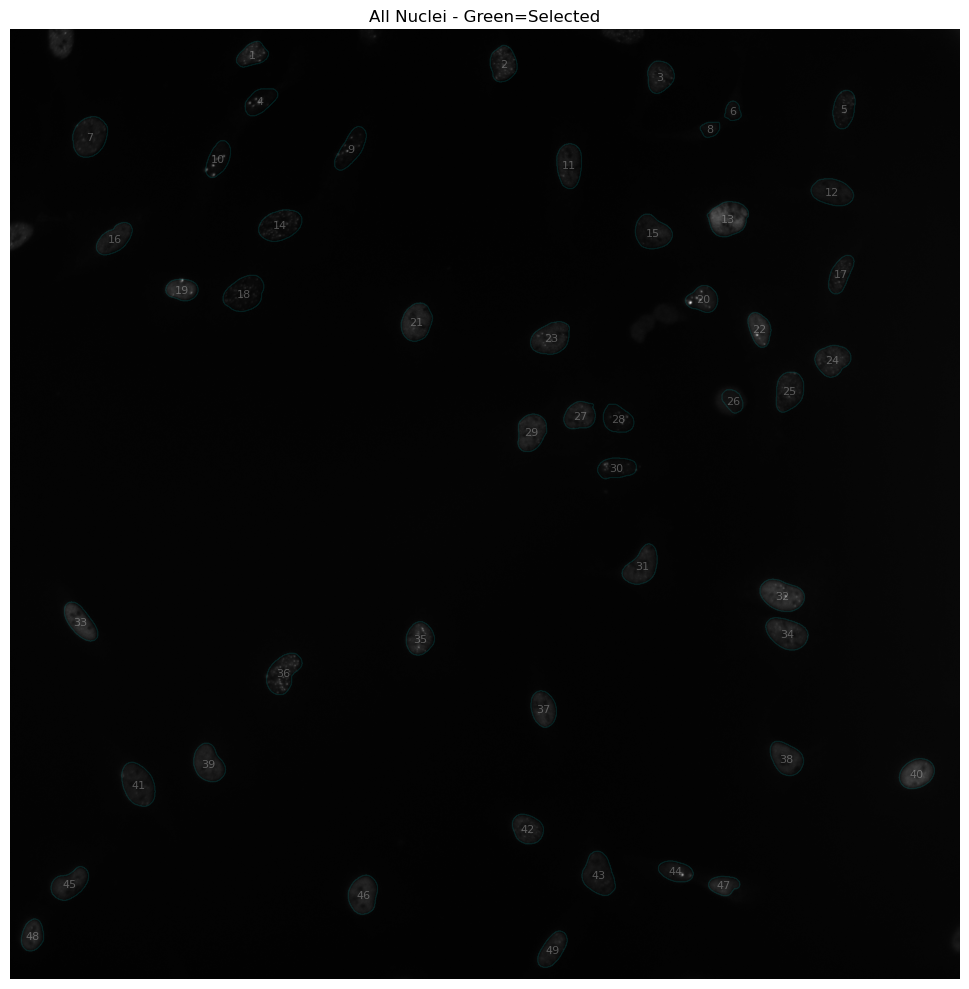


[0/10 nuclei selected]
📸 Current: Picture 1/15, Well 00032, Pos 00015



🔍 Enter nucleus ID to examine (or 'generate' to show overview, 'done' to finish, 'next'/'prev'/'picture' to change picture):  picture



🔍 CHOOSE PICTURE
Options:
  1. Enter picture index (e.g., '5')
  2. Enter well+position (e.g., 'w50p18' or 'W0050P0018')
  3. Type 'list' to see all pictures
  4. Type 'cancel' to go back



➤  list



📋 Available pictures:
  [  0] Well 00032, Position 00015 ← CURRENT
  [  1] Well 00029, Position 00035 
  [  2] Well 00026, Position 00005 
  [  3] Well 00044, Position 00021 
  [  4] Well 00041, Position 00005 
  [  5] Well 00038, Position 00017 
  [  6] Well 00056, Position 00018 
  [  7] Well 00053, Position 00016 
  [  8] Well 00050, Position 00018 
  [  9] Well 00068, Position 00024 
  [ 10] Well 00065, Position 00012 
  [ 11] Well 00062, Position 00010 
  [ 12] Well 00020, Position 00003 
  [ 13] Well 00017, Position 00004 
  [ 14] Well 00014, Position 00010 



➤  w26p5


✅ Switched to Well 00026, Position 00005


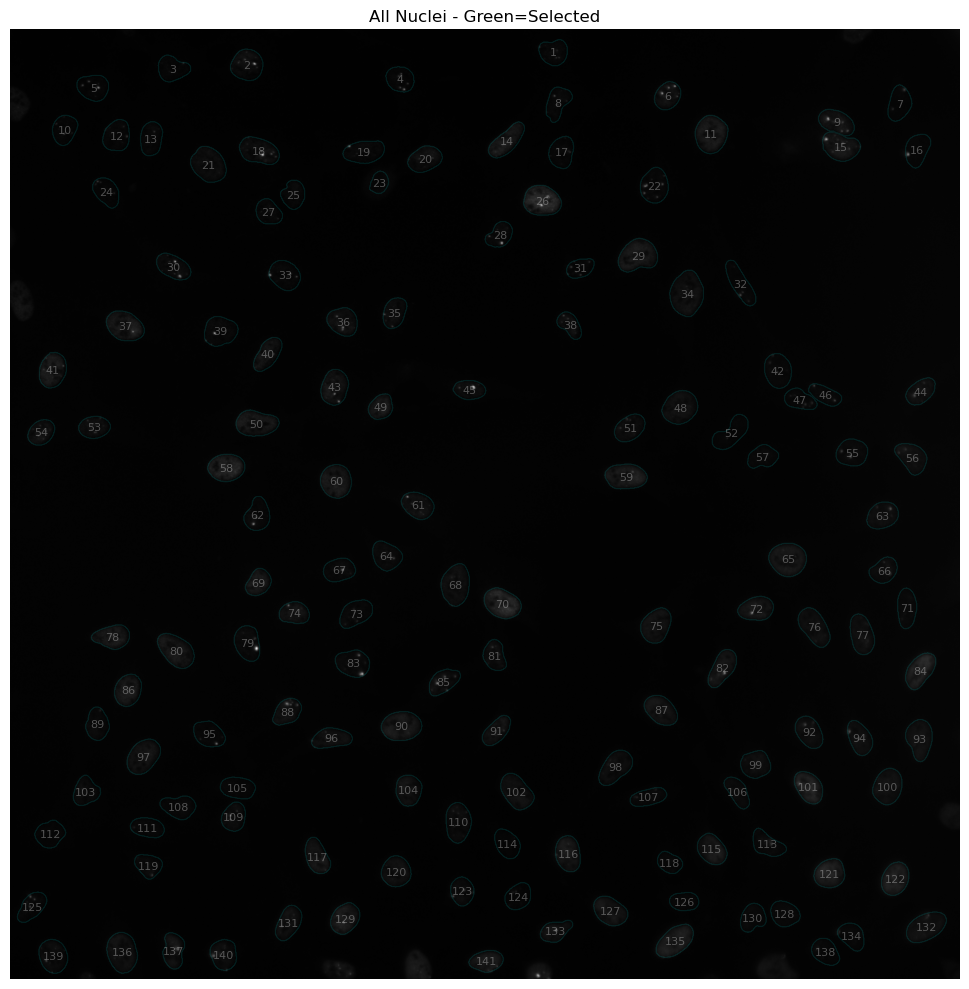

📸 Current: Picture 3/15, Well 00026, Pos 00005



🔍 Enter nucleus ID to examine (or 'generate' to show overview, 'done' to finish, 'next'/'prev'/'picture' to change picture):  111


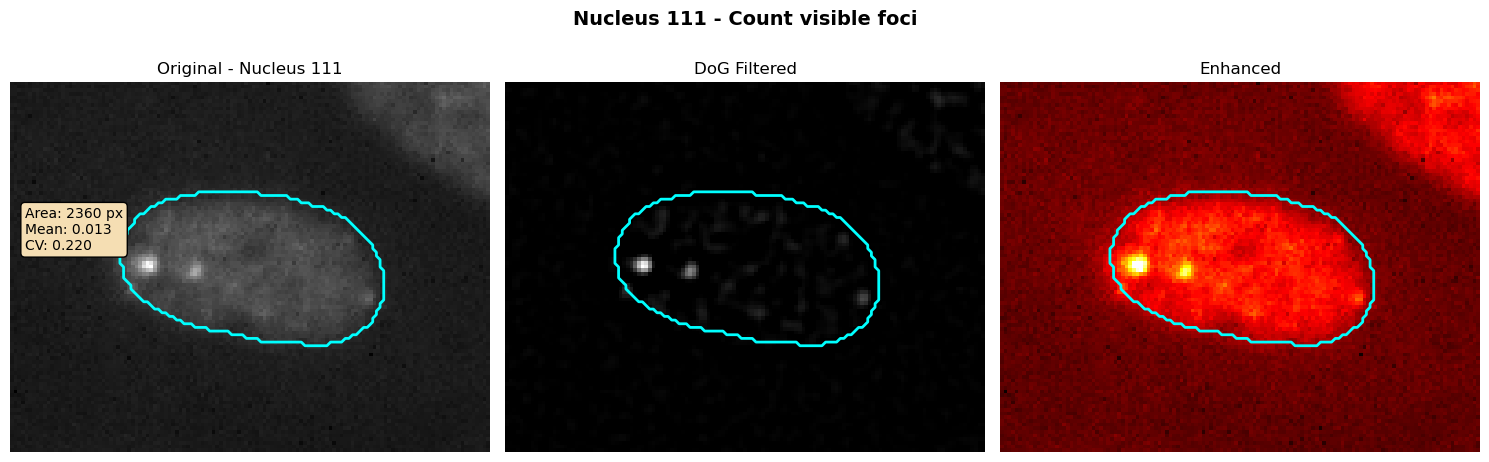

KeyboardInterrupt: Interrupted by user

In [ ]:
# ===============================================================
# GENERATE TRITC PARAMETER SPACE (OPTIONAL)
# ===============================================================
# This cell only executes if you set parameter_space.generate_new = true in config.yaml
# 
# PURPOSE: Create a validated set of detection parameters specifically for TRITC channel
# 
# WHAT HAPPENS:
# 1. Opens first TRITC image and displays all nuclei
# 2. User manually selects nuclei and counts foci in each
# 3. System tests thousands of parameter combinations
# 4. Keeps only parameters that correctly detect the annotated counts
# 5. Saves validated parameter space for future use
#
# WHEN TO RUN THIS:
# - First time analyzing a new dataset
# - After changing microscope settings
# - If current parameters give poor detection results
#
# TIME REQUIRED: 10-30 minutes (depends on number of nuclei annotated)
# ===============================================================

if Config.GENERATE_NEW_PARAMETER_SPACE:
    # ----------------------------------------------------------------
    # Set base directory where parameter space will be saved
    # ----------------------------------------------------------------
    # r"..." = raw string (backslashes treated as literal, not escape characters)
    # This creates: Y:\...\Complete_KDE\TRITC_parameter_space\
    base_output = r"Y:\Group Members\Valentin Aubry\01_Data\Parameters\Complete_KDE"
    
    # Print visual separator for this channel
    print("\n" + "🔴"*35)  # Red circles for TRITC (red channel)
    print("GENERATING PARAMETER SPACE FOR TRITC")
    print("🔴"*35)
    
    # ----------------------------------------------------------------
    # Call the parameter space generation function
    # ----------------------------------------------------------------
    # This is an INTERACTIVE function - will open matplotlib windows and
    # prompt for user input via console
    #
    # Parameters explained:
    # - channel_name: 'TRITC' - used for naming output files and display
    # - channel_data_paths: TRITC_data - list of all TRITC image file paths
    #   (loaded in previous cell, sorted to match other channels)
    # - mask_data_paths: DAPI_mask_data - corresponding nucleus segmentation masks
    #   (must be in same order as TRITC_data - same image positions)
    # - output_base_dir: base_output - where to save the parameter space
    #   Creates subdirectory: {base_output}/TRITC_parameter_space/
    # - num_nuclei: 10 - how many nuclei to manually annotate
    #   More nuclei = more robust but takes longer
    #   Recommended: 2-3 for quick testing, 10+ for production
    # - coverage_percentile: 85 - KDE coverage percentage
    #   Higher = more conservative (larger valid region)
    #   85% means include central 85% of probability mass
    #
    # RETURNS:
    # - tritc_generator: ParameterSpaceGenerator object with fitted parameters
    #   Not strictly needed (results are saved to disk), but useful for inspection
    tritc_generator = generate_parameter_space_for_channel(
        channel_name='TRITC',
        channel_data_paths=TRITC_data,
        mask_data_paths=DAPI_mask_data,
        output_base_dir=base_output,
        num_nuclei=10,  # Recommend 2-3 for quick setup, 10 for robust results
        coverage_percentile=85  # 85% is a balanced choice (not too loose, not too tight)
    )
    
    # ----------------------------------------------------------------
    # After this completes, you should:
    # 1. Set parameter_space.generate_new = false in config.yaml
    # 2. Set parameter_space.tritc_path to the output directory
    # 3. Re-run the notebook to use the generated parameter space
    # Note: Restart Kernel after changing the config.yaml
    # ----------------------------------------------------------------


🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢
GENERATING PARAMETER SPACE FOR FITC
🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢🟢

PARAMETER SPACE GENERATION FOR FITC CHANNEL

1️⃣ Loading FITC image and mask...
   ✓ Loaded: ATR1_24h--W00032--P00015--Z00000--T00000--FITC SEM.tif

2️⃣ Parameter ranges:
   bright_pct: 0 - 100
   contrast_thresh: 1 - 10
   percentile_val: 0 - 100

3️⃣ Creating parameter space generator...

4️⃣ STEP 1: Interactive nucleus selection
   Goal: Select 10 nuclei with known foci counts

INTERACTIVE VISUAL NUCLEUS SELECTION

Goal: Select and annotate up to 10 nuclei

Workflow:
  1. View full overview with all nucleus IDs
  2. Select a nucleus by entering its ID
  3. View detailed zoom of that nucleus
  4. Enter foci count or choose different nucleus

📊 Showing full overview of all nuclei...


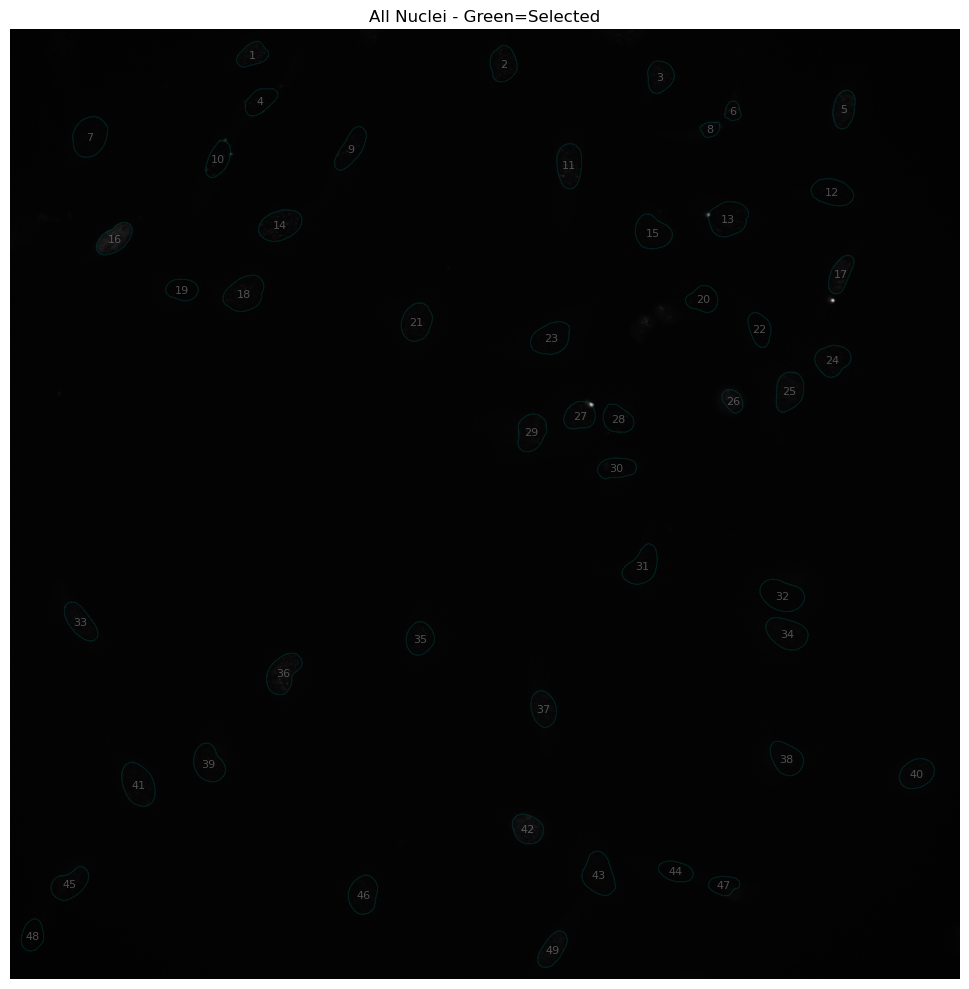


[0/10 nuclei selected]



🔍 Enter nucleus ID to examine (or 'generate' to show overview, 'done' to finish):  13


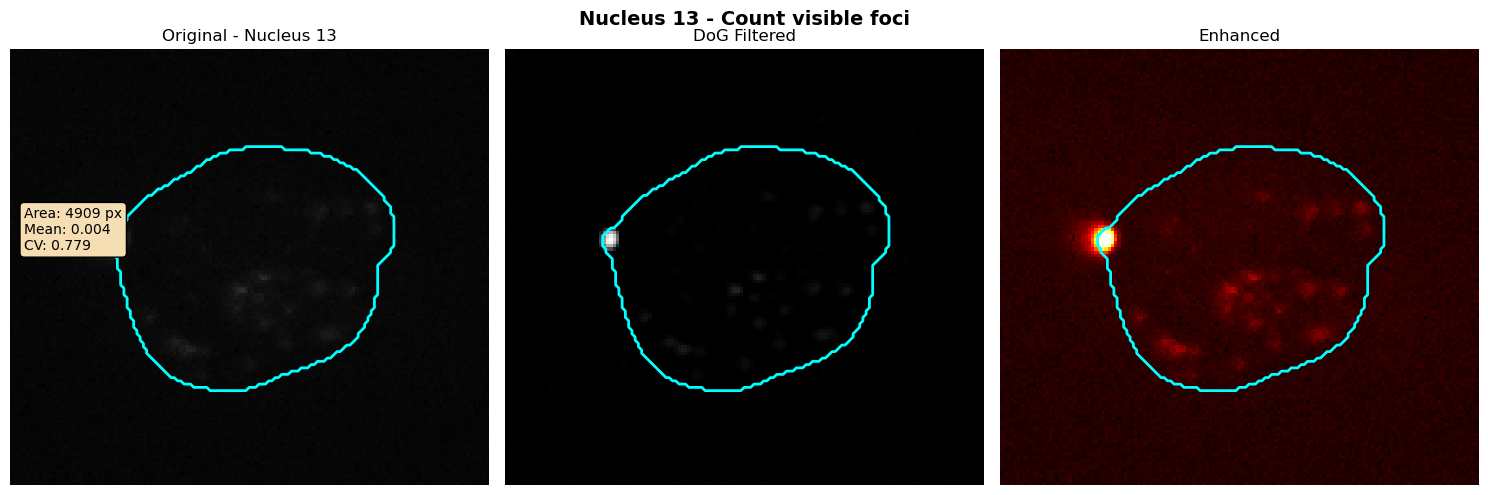


🎯 Nucleus 13 - Enter foci count (e.g., '3' or '2-4' for range), 'abort', or 'abort+':  abort


→ Aborting to nucleus selection...

[0/10 nuclei selected]



🔍 Enter nucleus ID to examine (or 'generate' to show overview, 'done' to finish):  27


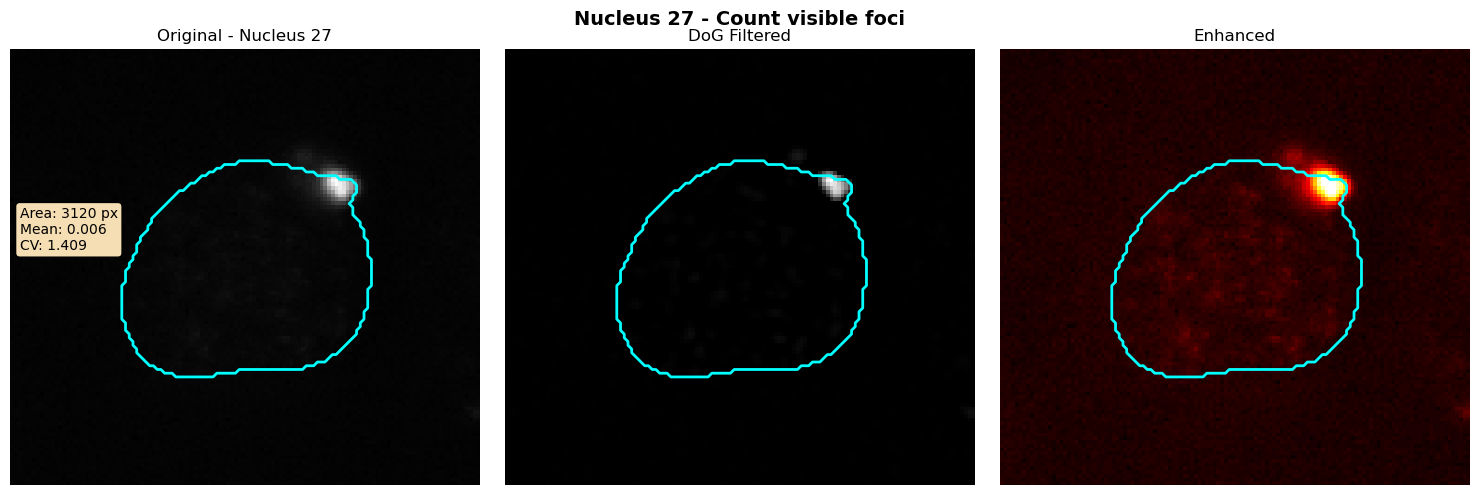


🎯 Nucleus 27 - Enter foci count (e.g., '3' or '2-4' for range), 'abort', or 'abort+':  1-2


✓ Added nucleus 27 with acceptable range: 1-2 foci
✓ Saved! (1/10 complete)

[1/10 nuclei selected]



🔍 Enter nucleus ID to examine (or 'generate' to show overview, 'done' to finish):  40


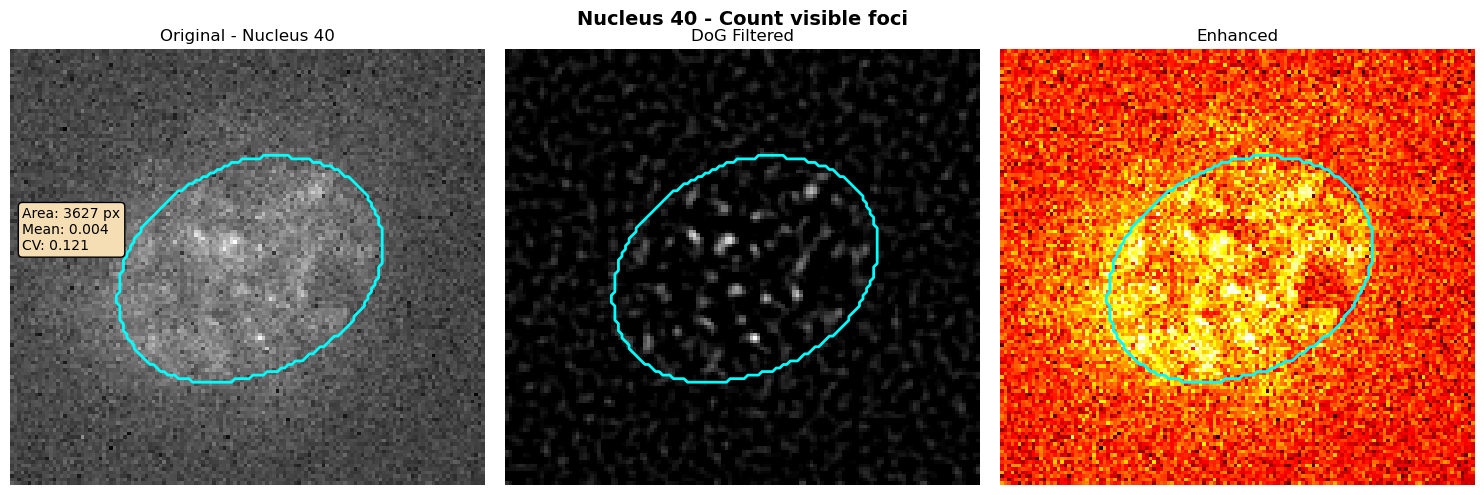


🎯 Nucleus 40 - Enter foci count (e.g., '3' or '2-4' for range), 'abort', or 'abort+':  abort


→ Aborting to nucleus selection...

[1/10 nuclei selected]



🔍 Enter nucleus ID to examine (or 'generate' to show overview, 'done' to finish):  10


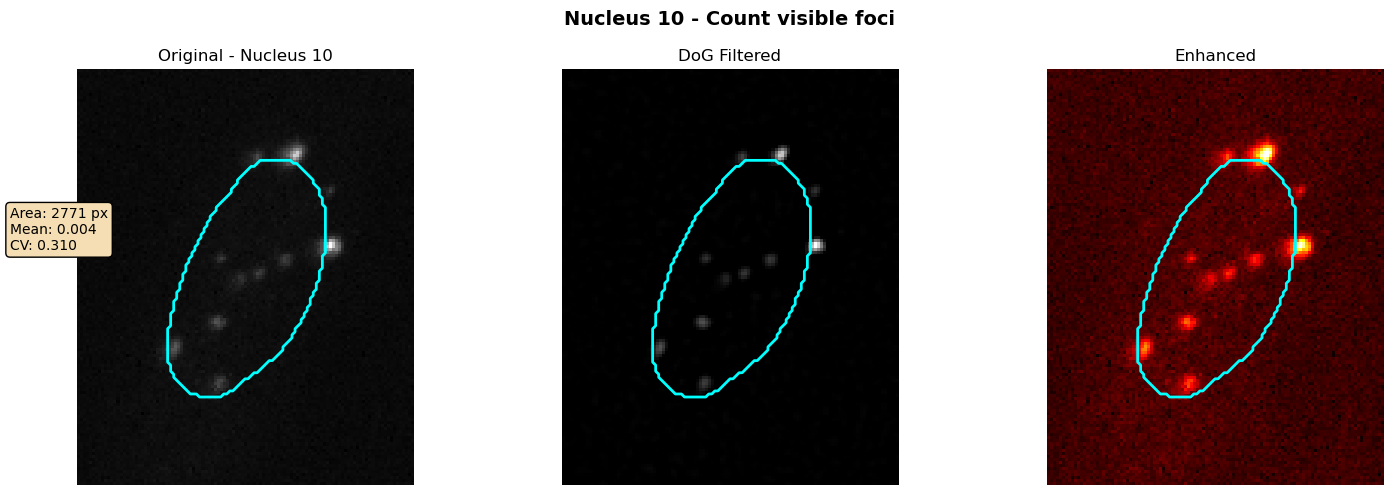


🎯 Nucleus 10 - Enter foci count (e.g., '3' or '2-4' for range), 'abort', or 'abort+':  7-11


✓ Added nucleus 10 with acceptable range: 7-11 foci
✓ Saved! (2/10 complete)

[2/10 nuclei selected]



🔍 Enter nucleus ID to examine (or 'generate' to show overview, 'done' to finish):  done



✓ Finished with 2 nuclei
   ✓ Selected 2 nuclei

5️⃣ STEP 2: Running grid search with foci detection...

STEP 2: GRID SEARCH WITH ACTUAL FOCI DETECTION

Testing 14415 parameter combinations
On 2 nuclei
  Bright %: 31 values from 0.0 to 100.0
  Contrast: 15 values from 1.00 to 10.00
  Percentile: 31 values from 0.0 to 100.0

Testing 14415 parameter combinations
On 2 nuclei

  Processing nucleus 27 (expected: 1-2 foci)...

    🔍 Debug nucleus 27:
      Max intensity in isolated nucleus: 0.099855
      Nucleus mask size: 3120 pixels
      Positive pixels in original: 4194304
      Global min brightness: 0.001236
      Range of min_brightness_per_param: 0.001236 - 0.120012
      Candidates (filtered): 58
      Candidates (unfiltered): 79
      Unfiltered intensity range: 0.004395 - 0.099855
      Filtered intensity range: 0.001272 - 0.099855
      Computing backgrounds for 31 unique brightness percentiles...
      Nucleus CV: 1.409
      Testing 14415 parameter combinations...
      ✅ Gen

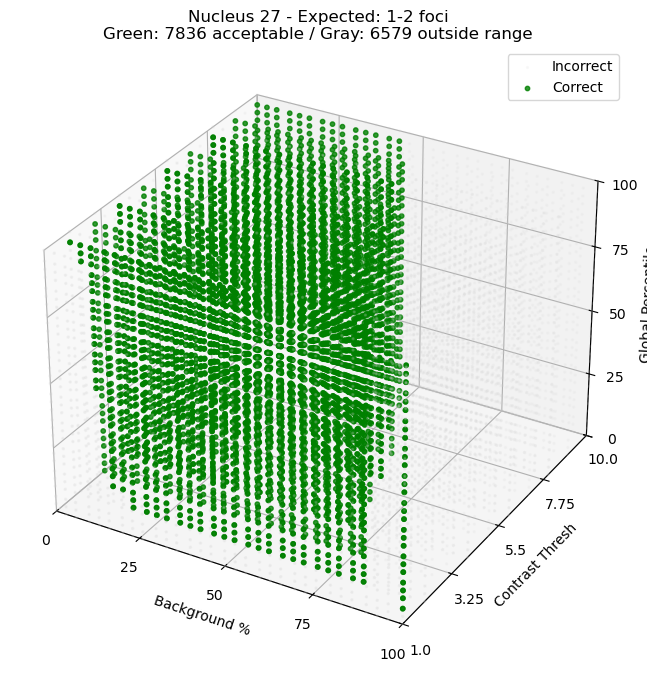

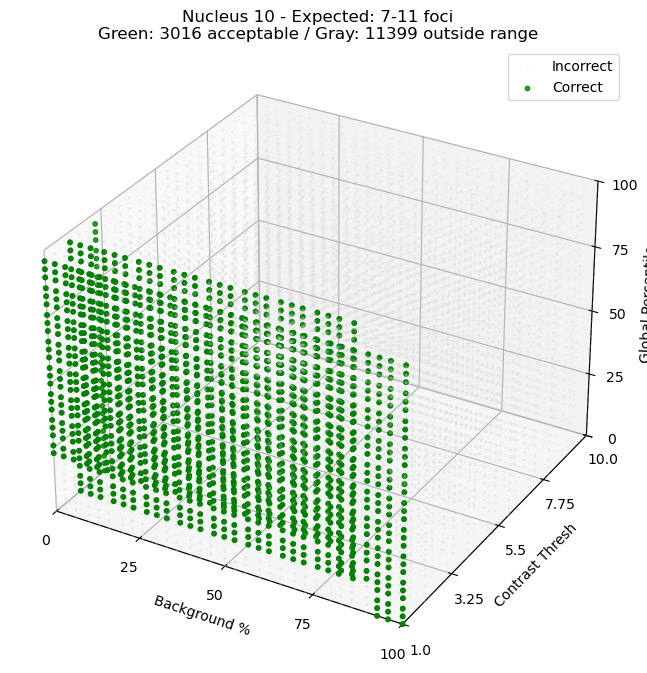

   ✓ Tested all parameter combinations

6️⃣ STEP 3: Finding valid parameter intersection...

STEP 3: FINDING VALID PARAMETER INTERSECTION
  Nucleus 27 (range: 1-2): 7836 valid combinations (54.4%)
  Nucleus 10 (range: 7-11): 3016 valid combinations (20.9%)

✓ Found 738 parameters valid for ALL nuclei


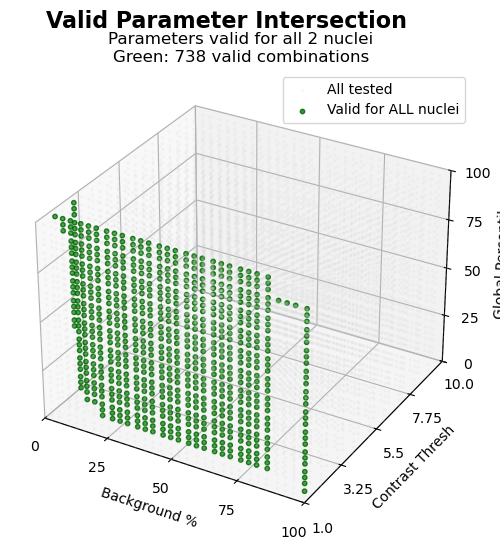

   ✓ Found 738 valid parameter combinations

7️⃣ STEP 4: Generating KDE parameter space...

STEP 4: GENERATING KDE PARAMETER SPACE

1. Finding optimal KDE bandwidth...
   Optimal bandwidth: 0.028

2. Fitting KDE model...

3. Generating isosurface...
   Generated 2192 isosurface points
   Coverage: 85%

4. Building Delaunay triangulation...

✓ KDE parameter space generated
  Bounding box:
    bright_pct: 3.61 - 79.17
    contrast_thresh: 1.79 - 2.21
    percentile_val: 0.00 - 96.27


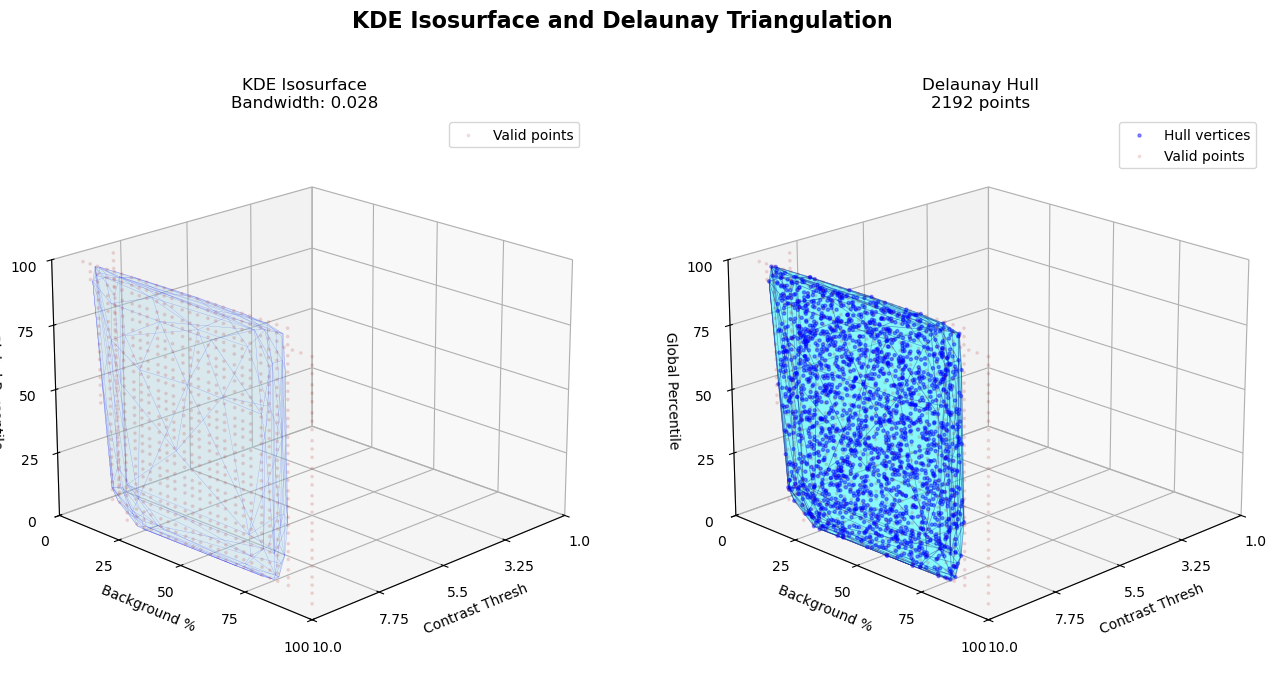

   ✓ KDE space generated with 85% coverage

8️⃣ STEP 5: Saving parameter space...
✓ Saved hull: Y:\Group Members\Valentin Aubry\01_Data\Parameters\Complete_KDE\FITC_parameter_space\valid_parameter_hull.pkl
✓ Saved bounds: Y:\Group Members\Valentin Aubry\01_Data\Parameters\Complete_KDE\FITC_parameter_space\parameter_bounds.npz
✓ Saved valid points: Y:\Group Members\Valentin Aubry\01_Data\Parameters\Complete_KDE\FITC_parameter_space\valid_points.npy
✓ Saved KDE metadata: Y:\Group Members\Valentin Aubry\01_Data\Parameters\Complete_KDE\FITC_parameter_space\kde_metadata.pkl

✓ Complete parameter space saved to: Y:\Group Members\Valentin Aubry\01_Data\Parameters\Complete_KDE\FITC_parameter_space
   ✓ Saved to: Y:\Group Members\Valentin Aubry\01_Data\Parameters\Complete_KDE\FITC_parameter_space

✅ PARAMETER SPACE GENERATION COMPLETE FOR FITC


In [ ]:
# ===============================================================
# GENERATE FITC PARAMETER SPACE (OPTIONAL)
# ===============================================================
# Only runs if Config.GENERATE_NEW_PARAMETER_SPACE = true
# This is an interactive process requiring manual nucleus annotation
# Same principle as the TRITC parameter space generation

if Config.GENERATE_NEW_PARAMETER_SPACE:
    base_output = r"Y:\Group Members\Valentin Aubry\01_Data\Parameters\Complete_KDE"
    
    print("\n" + "🟢"*35)
    print("GENERATING PARAMETER SPACE FOR FITC")
    print("🟢"*35)
    
    fitc_generator = generate_parameter_space_for_channel(
        channel_name='FITC',
        channel_data_paths=FITC_data,
        mask_data_paths=DAPI_mask_data,
        output_base_dir=base_output,
        num_nuclei=10,  # Recommend 2-3 for quick setup
        coverage_percentile=85
    )

In [ ]:
# ===============================================================
# MAIN PROCESSING LOOP
# ===============================================================
# This guard prevents worker processes from re-executing the script.
# CRITICAL for Windows multiprocessing: when ProcessPoolExecutor spawns
# worker processes, they re-import the main module. Without this guard,
# workers would re-run all the setup code above (loading config, data, etc.)
if __name__ == '__main__':
    
    # ================================================================
    # START RUNTIME TIMER
    # ================================================================
    # Record start time to measure total processing duration
    start_time = time.time()
    
    # ================================================================
    # LOAD PARAMETER SPACES (Delaunay Hulls & Bounds)
    # ================================================================
    # Load the pre-computed convex hulls that define valid parameter regions.
    # These were created during parameter space generation (optional cells above).
    # 
    # The hull is a 3D shape in parameter space containing all validated
    # parameter combinations. We'll use it to filter Sobol samples.
    
    # Load TRITC hull (Delaunay triangulation object)
    tritc_hull_path = os.path.join(Config.TRITC_PARAMETER_SPACE_PATH, "valid_parameter_hull.pkl")
    with open(tritc_hull_path, "rb") as f:
        delaunay_TRITC = pickle.load(f)

    # Load FITC hull (Delaunay triangulation object)
    fitc_hull_path = os.path.join(Config.FITC_PARAMETER_SPACE_PATH, "valid_parameter_hull.pkl")
    with open(fitc_hull_path, "rb") as f:
        delaunay_FITC = pickle.load(f)
    
    # Load parameter bounds (min/max for each parameter dimension)
    # These define the bounding box around the hull for scaling Sobol samples
    tritc_bounds_path = os.path.join(Config.TRITC_PARAMETER_SPACE_PATH, "parameter_bounds.npz")
    param_bounds_TRITC = dict(np.load(tritc_bounds_path))

    fitc_bounds_path = os.path.join(Config.FITC_PARAMETER_SPACE_PATH, "parameter_bounds.npz")
    param_bounds_FITC = dict(np.load(fitc_bounds_path))
    
    # ================================================================
    # DEFINE HELPER FUNCTION: in_hull
    # ================================================================
    # Must be defined here (inside if __name__ == '__main__':) even though
    # there's a version in the helper functions cell, because this function
    # needs to be picklable for multiprocessing and available in this scope.
    
    def in_hull(p, delaunay_obj):
        """
        Test if points are inside a convex hull.
        
        Uses Delaunay triangulation's find_simplex method:
        - Returns >= 0 if point is inside a simplex (inside hull)
        - Returns -1 if point is outside all simplices (outside hull)
        
        Parameters:
        -----------
        p : ndarray, shape (N, 3)
            Points to test in 3D parameter space
        delaunay_obj : scipy.spatial.Delaunay
            Delaunay triangulation representing the convex hull
            
        Returns:
        --------
        ndarray : Boolean mask (True = inside, False = outside)
        """
        return delaunay_obj.find_simplex(p) >= 0
    
    
    # ================================================================
    # GENERATE STRATIFIED PARAMETER SAMPLES FOR TRITC
    # ================================================================
    # Use Sobol sequence (quasi-random) to densely sample parameter space,
    # then filter to points inside the validated hull, then select a diverse
    # subset using farthest-point sampling.
    
    print("\n🔸 Generating TRITC parameter samples...")
    
    # ----------------------------------------------------------------
    # Step 1: Generate Sobol samples in unit hypercube [0,1]^3
    # ----------------------------------------------------------------
    # Sobol sequence provides better coverage than pure random sampling
    # d=3: 3 parameters (bright_pct, contrast_thresh, percentile_val)
    # scramble=True: randomizes the sequence for better properties
    sampler_TRITC = qmc.Sobol(d=3, scramble=True)
    
    # Generate N_SOBOL_SAMPLES points in [0,1]^3
    # Typically 65536 (2^16) for dense coverage
    unit_samples_TRITC = sampler_TRITC.random(n=Config.N_SOBOL_SAMPLES)
    
    # ----------------------------------------------------------------
    # Step 2: Scale from [0,1]^3 to actual parameter ranges
    # ----------------------------------------------------------------
    # Transform unit hypercube samples to match the parameter bounds
    # from the loaded parameter space (e.g., bright_pct: 4-88, etc.)
    scaled_samples_TRITC = qmc.scale(
        unit_samples_TRITC,
        l_bounds=[
            param_bounds_TRITC["bright_pct"][0],      # Lower bound for brightness percentile
            param_bounds_TRITC["contrast_thresh"][0],  # Lower bound for contrast threshold
            param_bounds_TRITC["percentile_val"][0],   # Lower bound for global percentile
        ],
        u_bounds=[
            param_bounds_TRITC["bright_pct"][1],      # Upper bound for brightness percentile
            param_bounds_TRITC["contrast_thresh"][1],  # Upper bound for contrast threshold
            param_bounds_TRITC["percentile_val"][1],   # Upper bound for global percentile
        ],
    )
    
    # ----------------------------------------------------------------
    # Step 3: Filter to points inside the Delaunay hull
    # ----------------------------------------------------------------
    # The hull defines the "known good" region. Points outside may not work.
    # in_hull() returns boolean mask: True for points inside hull
    inside_mask_TRITC = in_hull(scaled_samples_TRITC, delaunay_TRITC)
    
    # Extract only the valid points (inside hull)
    valid_points_TRITC = scaled_samples_TRITC[inside_mask_TRITC]
    n_valid_TRITC = len(valid_points_TRITC)
    
    # Print diagnostic: what percentage of Sobol samples fell inside hull?
    # Low percentage might indicate hull is too restrictive
    print(f"  📊 Hull filtering: {n_valid_TRITC}/{Config.N_SOBOL_SAMPLES} points inside hull ({100*n_valid_TRITC/Config.N_SOBOL_SAMPLES:.1f}%)")
    
    # ----------------------------------------------------------------
    # Step 4: Validate we have enough valid points
    # ----------------------------------------------------------------
    # We need at least N_PARAMETER_SAMPLES valid points to select from
    # If insufficient, we cannot proceed - need to adjust config or regenerate hull
    if n_valid_TRITC < Config.N_PARAMETER_SAMPLES:
        print(f"\n❌ ERROR: Insufficient valid points in TRITC Delaunay hull!")
        print(f"  • Required: {Config.N_PARAMETER_SAMPLES} points")
        print(f"  • Available: {n_valid_TRITC} points")
        print(f"  • Deficit: {Config.N_PARAMETER_SAMPLES - n_valid_TRITC} points")
        print(f"\n💡 Possible solutions:")
        print(f"  1. Increase Config.N_SOBOL_SAMPLES (current: {Config.N_SOBOL_SAMPLES})")
        print(f"     Try: Config.N_SOBOL_SAMPLES = 65536 (2^16) or 131072 (2^17)")
        print(f"  2. Decrease Config.N_PARAMETER_SAMPLES (current: {Config.N_PARAMETER_SAMPLES})")
        print(f"     Try: Config.N_PARAMETER_SAMPLES = {n_valid_TRITC} or lower")
        print(f"  3. Check your TRITC Delaunay hull:")
        print(f"     • Is the hull too restrictive?")
        print(f"     • Was it trained on sufficient data?")
        print(f"     • File: valid_parameter_hull_TRITC.pkl")
        print(f"  4. Verify parameter bounds are reasonable:")
        print(f"     • Bright %: {param_bounds_TRITC['bright_pct']}")
        print(f"     • Contrast: {param_bounds_TRITC['contrast_thresh']}")
        print(f"     • Percentile: {param_bounds_TRITC['percentile_val']}")
        raise ValueError(f"Cannot generate {Config.N_PARAMETER_SAMPLES} samples from only {n_valid_TRITC} valid points")
    
    # ----------------------------------------------------------------
    # Step 5: Apply farthest-point sampling for even coverage
    # ----------------------------------------------------------------
    # From the valid points, select N_PARAMETER_SAMPLES (e.g., 256) that are
    # maximally spread apart. This ensures good coverage of parameter space.
    valid_param_samples_TRITC = farthest_point_sampling(valid_points_TRITC, n_samples=Config.N_PARAMETER_SAMPLES)
    total_iterations_TRITC = len(valid_param_samples_TRITC)
    
    # Report success and show parameter ranges of selected samples
    print(f"  ✅ Generated {len(valid_param_samples_TRITC)} valid TRITC parameter combinations")
    print(f"    Bright %: {valid_param_samples_TRITC[:,0].min():.1f}-{valid_param_samples_TRITC[:,0].max():.1f}")
    print(f"    Contrast: {valid_param_samples_TRITC[:,1].min():.2f}-{valid_param_samples_TRITC[:,1].max():.2f}")
    print(f"    Percentile: {valid_param_samples_TRITC[:,2].min():.1f}-{valid_param_samples_TRITC[:,2].max():.1f}")
    
    
    # ================================================================
    # GENERATE STRATIFIED PARAMETER SAMPLES FOR FITC
    # ================================================================
    # Identical process to TRITC above, but for FITC channel
    # FITC typically has different optimal parameters than TRITC due to
    # different fluorophore properties and signal-to-noise characteristics
    
    print("\n🔸 Generating FITC parameter samples...")
    
    # Generate Sobol samples in [0,1]^3
    sampler_FITC = qmc.Sobol(d=3, scramble=True)
    unit_samples_FITC = sampler_FITC.random(n=Config.N_SOBOL_SAMPLES)
    
    # Scale to FITC parameter bounds
    scaled_samples_FITC = qmc.scale(
        unit_samples_FITC,
        l_bounds=[
            param_bounds_FITC["bright_pct"][0],
            param_bounds_FITC["contrast_thresh"][0],
            param_bounds_FITC["percentile_val"][0],
        ],
        u_bounds=[
            param_bounds_FITC["bright_pct"][1],
            param_bounds_FITC["contrast_thresh"][1],
            param_bounds_FITC["percentile_val"][1],
        ],
    )
    
    # Filter to points inside FITC hull
    inside_mask_FITC = in_hull(scaled_samples_FITC, delaunay_FITC)
    valid_points_FITC = scaled_samples_FITC[inside_mask_FITC]
    n_valid_FITC = len(valid_points_FITC)
    
    print(f"  📊 Hull filtering: {n_valid_FITC}/{Config.N_SOBOL_SAMPLES} points inside hull ({100*n_valid_FITC/Config.N_SOBOL_SAMPLES:.1f}%)")
    
    # Validate sufficient points
    if n_valid_FITC < Config.N_PARAMETER_SAMPLES:
        print(f"\n❌ ERROR: Insufficient valid points in FITC Delaunay hull!")
        print(f"  • Required: {Config.N_PARAMETER_SAMPLES} points")
        print(f"  • Available: {n_valid_FITC} points")
        print(f"  • Deficit: {Config.N_PARAMETER_SAMPLES - n_valid_FITC} points")
        print(f"\n💡 Possible solutions:")
        print(f"  1. Increase Config.N_SOBOL_SAMPLES (current: {Config.N_SOBOL_SAMPLES})")
        print(f"     Try: Config.N_SOBOL_SAMPLES = 65536 (2^16) or 131072 (2^17)")
        print(f"  2. Decrease Config.N_PARAMETER_SAMPLES (current: {Config.N_PARAMETER_SAMPLES})")
        print(f"     Try: Config.N_PARAMETER_SAMPLES = {n_valid_FITC} or lower")
        print(f"  3. Check your FITC Delaunay hull:")
        print(f"     • Is the hull too restrictive?")
        print(f"     • Was it trained on sufficient data?")
        print(f"     • File: valid_parameter_hull_FITC.pkl")
        print(f"  4. Verify parameter bounds are reasonable:")
        print(f"     • Bright %: {param_bounds_FITC['bright_pct']}")
        print(f"     • Contrast: {param_bounds_FITC['contrast_thresh']}")
        print(f"     • Percentile: {param_bounds_FITC['percentile_val']}")
        raise ValueError(f"Cannot generate {Config.N_PARAMETER_SAMPLES} samples from only {n_valid_FITC} valid points")
    
    # Apply farthest-point sampling
    valid_param_samples_FITC = farthest_point_sampling(valid_points_FITC, n_samples=Config.N_PARAMETER_SAMPLES)
    total_iterations_FITC = len(valid_param_samples_FITC)
    
    # Report success
    print(f"  ✅ Generated {len(valid_param_samples_FITC)} valid FITC parameter combinations")
    print(f"    Bright %: {valid_param_samples_FITC[:,0].min():.1f}-{valid_param_samples_FITC[:,0].max():.1f}")
    print(f"    Contrast: {valid_param_samples_FITC[:,1].min():.2f}-{valid_param_samples_FITC[:,1].max():.2f}")
    print(f"    Percentile: {valid_param_samples_FITC[:,2].min():.1f}-{valid_param_samples_FITC[:,2].max():.1f}")
    
    
    # ================================================================
    # SUMMARY STATISTICS
    # ================================================================
    # Print overall summary of parameter space coverage for both channels
    print(f"\n📊 Parameter Space Coverage Summary:")
    print(f"  TRITC: {n_valid_TRITC}/{Config.N_SOBOL_SAMPLES} valid points ({100*n_valid_TRITC/Config.N_SOBOL_SAMPLES:.1f}%) → {len(valid_param_samples_TRITC)} selected")
    print(f"  FITC:  {n_valid_FITC}/{Config.N_SOBOL_SAMPLES} valid points ({100*n_valid_FITC/Config.N_SOBOL_SAMPLES:.1f}%) → {len(valid_param_samples_FITC)} selected")
    


    # ================================================================
    # ADAPTIVE PARAMETER SELECTION SETUP
    # ================================================================
    # If enabled, this system learns optimal parameters from calibration images
    # instead of using all 256 parameters on every image.
    #
    # WORKFLOW:
    # 1. Calibration phase: Test all 256 parameters on first N images
    # 2. Analysis: Find which 1-3 parameters work best across images
    # 3. Production phase: Use only those 1-3 parameters on remaining images
    #
    # RESULT: Much faster processing after calibration (3 iterations vs 256)
    
    if Config.USE_ADAPTIVE_PARAMETERS:
        print("\n" + "="*70)
        print("🎯 ADAPTIVE PARAMETER SELECTION ENABLED")
        print("="*70)
        
        # ----------------------------------------------------------------
        # Check if we should load pre-optimized parameters
        # ----------------------------------------------------------------
        # If user ran calibration before and saved optimal parameters,
        # they can skip the calibration phase entirely by loading them
        
        if Config.LOAD_REDUCED_PARAMETERS:
            print("\n📂 LOADING PRE-OPTIMIZED PARAMETERS")
            print("-"*70)
            
            try:
                # Initialize tracker objects (even though we're loading, need objects for structure)
                tritc_tracker = AdaptiveParameterSelector(
                    n_calibration_images=Config.N_CALIBRATION_IMAGES,
                    n_final_params=Config.N_PRODUCTION_PARAMS
                )
                
                fitc_tracker = AdaptiveParameterSelector(
                    n_calibration_images=Config.N_CALIBRATION_IMAGES,
                    n_final_params=Config.N_PRODUCTION_PARAMS
                )
                
                # Load the pre-saved optimal parameters (1-3 combinations per channel)
                # These were saved from a previous calibration run
                # ⚠️ This OVERWRITES the 256 parameters we just generated above
                valid_param_samples_TRITC = tritc_tracker.load_reduced_parameters(
                    Config.REDUCED_TRITC_PATH, 
                    'TRITC'
                )
                
                valid_param_samples_FITC = fitc_tracker.load_reduced_parameters(
                    Config.REDUCED_FITC_PATH,
                    'FITC'
                )
                
                # Update iteration counts (now 1-3 instead of 256)
                total_iterations_TRITC = len(valid_param_samples_TRITC)
                total_iterations_FITC = len(valid_param_samples_FITC)
                
                # Mark calibration as complete (skip calibration phase in main loop)
                calibration_complete = True
                print(f"✅ Using {total_iterations_TRITC} TRITC and {total_iterations_FITC} FITC parameters")
                print("-"*70)
                
            except Exception as e:
                # Loading failed - fall back to calibration mode
                print(f"⚠️ Could not load reduced parameters: {e}")
                print(f"   Falling back to calibration mode")
                calibration_complete = False
                
                # Initialize trackers for fresh calibration
                tritc_tracker = AdaptiveParameterSelector(
                    n_calibration_images=Config.N_CALIBRATION_IMAGES,
                    n_final_params=Config.N_PRODUCTION_PARAMS
                )
                
                fitc_tracker = AdaptiveParameterSelector(
                    n_calibration_images=Config.N_CALIBRATION_IMAGES,
                    n_final_params=Config.N_PRODUCTION_PARAMS
                )
        else:
            # Not loading parameters - initialize trackers for fresh calibration
            tritc_tracker = AdaptiveParameterSelector(
                n_calibration_images=Config.N_CALIBRATION_IMAGES,
                n_final_params=Config.N_PRODUCTION_PARAMS
            )
            
            fitc_tracker = AdaptiveParameterSelector(
                n_calibration_images=Config.N_CALIBRATION_IMAGES,
                n_final_params=Config.N_PRODUCTION_PARAMS
            )
            
            calibration_complete = False
            print(f"Starting fresh calibration with {Config.N_CALIBRATION_IMAGES} images...")


    # ================================================================
    # WATERSHED THRESHOLD CONFIGURATION
    # ================================================================
    # Watershed segmentation needs a brightness threshold to separate foci.
    # Two modes available:
    # 1. Interactive: Analyze images, show histogram, user picks threshold
    # 2. Preset: Use fixed thresholds from config.yaml
    
    configurator = WatershedConfigurator()
    
    # Determine if we need interactive configuration
    # Only run interactive mode if:
    # - Mode is "manual_interactive" AND
    # - Skip flag is not set
    need_threshold_config = (
        Config.WATERSHED_MODE == "manual_interactive" and 
        not Config._config['watershed']['skip_interactive_config']
    )
    
    if need_threshold_config:
        # ----------------------------------------------------------------
        # INTERACTIVE MODE: Analyze images and get user input
        # ----------------------------------------------------------------
        print("\n" + "="*70)
        print("🎨 WATERSHED THRESHOLD CONFIGURATION")
        print("="*70)
        print("Analyzing first few images to determine optimal thresholds...")
        print("="*70 + "\n")
        
        # Get number of images to analyze from config
        n_images_to_analyze = Config._config['watershed']['n_images_for_threshold']
        
        # Select which images to analyze
        # If randomization is enabled, use the randomized order
        if Config.RANDOMIZE_CALIBRATION_ORDER:
            # Use first N images from randomized order
            analysis_indices = all_indices[:n_images_to_analyze]
            tritc_paths_to_analyze = [TRITC_data[idx] for idx in analysis_indices]
            fitc_paths_to_analyze = [FITC_data[idx] for idx in analysis_indices]
        else:
            # Use first N images in sequential order
            tritc_paths_to_analyze = TRITC_data[:n_images_to_analyze]
            fitc_paths_to_analyze = FITC_data[:n_images_to_analyze]
        
        # Run interactive configuration
        # Shows brightness histograms and prompts user to pick thresholds
        GLOBAL_TRITC_THRESHOLD, GLOBAL_FITC_THRESHOLD = \
            configurator.configure_threshold_from_multi_image(
                tritc_paths=tritc_paths_to_analyze,
                fitc_paths=fitc_paths_to_analyze,
                n_images=n_images_to_analyze,
                folder_path=folder_path
            )
        
        print(f"\n✅ Thresholds configured. Will apply to all {len(DAPI_data)} images.")
        
    elif Config.WATERSHED_MODE == "manual_preset" or Config._config['watershed']['skip_interactive_config']:
        # ----------------------------------------------------------------
        # PRESET MODE: Use thresholds from config.yaml
        # ----------------------------------------------------------------
        GLOBAL_TRITC_THRESHOLD = Config.MANUAL_WATERSHED_THRESHOLD_TRITC
        GLOBAL_FITC_THRESHOLD = Config.MANUAL_WATERSHED_THRESHOLD_FITC
        
        print("\n" + "="*70)
        print("📋 USING PRESET WATERSHED THRESHOLDS")
        print("="*70)
        print(f"   TRITC: {GLOBAL_TRITC_THRESHOLD}")
        print(f"   FITC:  {GLOBAL_FITC_THRESHOLD}")
        print("="*70 + "\n")
    
    else:
        # Unknown mode - configuration error
        raise ValueError(f"Unknown watershed mode: {Config.WATERSHED_MODE}")





    
    # ================================================================
    # PROCESSING MODE SUMMARY
    # ================================================================
    # Print summary of settings before starting main processing loop
    print("\n" + "="*70)
    print("🚀 PROCESSING MODE")
    print("="*70)
    print(f"Watershed thresholds:")
    print(f"  TRITC: {GLOBAL_TRITC_THRESHOLD}")
    print(f"  FITC:  {GLOBAL_FITC_THRESHOLD}")
    print(f"Visualization mode: {Config.VISUALIZATION_MODE}")
    print(f"Processing all {len(DAPI_data)} images")
    print("="*70 + "\n")
    
    num_images_to_process = len(DAPI_data)
    
    # ================================================================
    # INITIALIZE DATA ACCUMULATORS
    # ================================================================
    # These lists will accumulate results from all images
    # Each worker process will append results here (thread-safe)
    
    # List to store all detected foci across all images
    # Each entry is a dictionary with foci properties (location, intensity, etc.)
    all_foci_data = []
    
    # List to store all nucleus-level data across all images
    # Each entry is a dictionary with nucleus properties (area, mean intensity, etc.)
    all_nuclei_data = []
     
    
    # ================================================================
    # HIGH THROUGHPUT DATA LOADING LOOP
    # ================================================================
    # Process each image in the processing_indices list
    # This list was created in data loading cell based on resume settings
    
    for loop_idx, i in enumerate(processing_indices):
        # ----------------------------------------------------------------
        # CHECK IF CALIBRATION JUST COMPLETED
        # ----------------------------------------------------------------
        # This check happens BEFORE building tasks for current image
        # If we just finished calibrating, we need to switch to production parameters
        
        # Initialize lists for CURRENT IMAGE only (for visualization)
        # These are separate from all_foci_data/all_nuclei_data which accumulate across ALL images
        current_image_foci = []
        current_image_nuclei = []
        
        # Check if we just completed calibration phase
        # Conditions: adaptive enabled, reached calibration limit, not already marked complete
        if (Config.USE_ADAPTIVE_PARAMETERS and 
            loop_idx == Config.N_CALIBRATION_IMAGES and 
            not calibration_complete):
            
            print("\n" + "="*70)
            print("📊 CALIBRATION COMPLETE - SELECTING OPTIMAL PARAMETERS")
            print("="*70)
            
            # --------------------------------------------------------
            # Analyze calibration results and select optimal parameters
            # --------------------------------------------------------
            # The trackers have accumulated results from calibration images
            # Now we analyze which parameters worked best
            
            print("\n🔴 TRITC Channel:")
            selected_tritc = tritc_tracker.select_optimal_parameters_auto(channel='TRITC')
            
            print("\n🟢 FITC Channel:")
            selected_fitc = fitc_tracker.select_optimal_parameters_auto(channel='FITC')
            
            # --------------------------------------------------------
            # Save full calibration results (for inspection/debugging)
            # --------------------------------------------------------
            # Create directory if needed
            os.makedirs(os.path.dirname(Config.CALIBRATION_SAVE_PATH), exist_ok=True)
            
            # Save full calibration data (all tested parameters and results)
            tritc_tracker.save_calibration(Config.CALIBRATION_SAVE_PATH.replace('.pkl', '_TRITC.pkl'))
            fitc_tracker.save_calibration(Config.CALIBRATION_SAVE_PATH.replace('.pkl', '_FITC.pkl'))
            
            # --------------------------------------------------------
            # Save reduced parameters (just the optimal 1-3 combinations)
            # --------------------------------------------------------
            # Need to import pickle again here (local scope)
            import pickle
            
            # Save TRITC optimal parameters
            os.makedirs(os.path.dirname(Config.REDUCED_TRITC_PATH), exist_ok=True)
            with open(Config.REDUCED_TRITC_PATH, 'wb') as f:
                pickle.dump(selected_tritc, f)
            print(f"✅ Saved reduced TRITC parameters to {Config.REDUCED_TRITC_PATH}")
            
            # Save FITC optimal parameters
            os.makedirs(os.path.dirname(Config.REDUCED_FITC_PATH), exist_ok=True)
            with open(Config.REDUCED_FITC_PATH, 'wb') as f:
                pickle.dump(selected_fitc, f)
            print(f"✅ Saved reduced FITC parameters to {Config.REDUCED_FITC_PATH}")
            
            print(f"\n💾 Reduced parameters saved for future runs")
            print(f"   To use them next time, set in config.yaml:")
            print(f"   adaptive_parameters:")
            print(f"     load_reduced_parameters: true")
            
            # --------------------------------------------------------
            # Generate visualizations of parameter space and selections
            # --------------------------------------------------------
            tritc_tracker.visualize_parameter_space('TRITC', Config.CALIBRATION_SAVE_PATH.replace('.pkl', '_TRITC_viz.png'))
            fitc_tracker.visualize_parameter_space('FITC', Config.CALIBRATION_SAVE_PATH.replace('.pkl', '_FITC_viz.png'))
            
            # --------------------------------------------------------
            # UPDATE PARAMETERS FOR ALL REMAINING IMAGES
            # --------------------------------------------------------
            # ⚠️ CRITICAL: This overwrites the 256 parameters with just 1-3 optimal ones
            # All subsequent images will use only these optimized parameters
            valid_param_samples_TRITC = np.array(selected_tritc)
            valid_param_samples_FITC = np.array(selected_fitc)
            total_iterations_TRITC = len(valid_param_samples_TRITC)
            total_iterations_FITC = len(valid_param_samples_FITC)
            
            # Mark calibration as complete
            calibration_complete = True
            
            print(f"\n✅ PARAMETERS UPDATED FOR PRODUCTION")
            print(f"   TRITC: {total_iterations_TRITC} parameter(s)")
            print(f"   FITC: {total_iterations_FITC} parameter(s)")
            print(f"   All remaining images will use optimized parameters")
            print("="*70 + "\n")
        
        # ----------------------------------------------------------------
        # NOW PROCESS THIS IMAGE
        # ----------------------------------------------------------------
        
        # Calculate global position for display (1-based indexing for humans)
        global_position = start_idx + loop_idx + 1
        
        print(f"\n{'='*70}")
        print(f"📸 Processing Image {global_position}/{total_images} (Dataset Index: {i})")
        if resume_from > 0:
            print(f"   (Run progress: {loop_idx+1}/{len(processing_indices)})")
        print(f"{'='*70}")
        
        # Determine if we're in calibration phase
        # Calibration: testing many parameters to find best ones
        # Production: using already-optimized parameters
        in_calibration = (Config.USE_ADAPTIVE_PARAMETERS and 
                         not calibration_complete and 
                         loop_idx < Config.N_CALIBRATION_IMAGES)
        
        if in_calibration:
            print(f"🔬 CALIBRATION MODE: Image {loop_idx+1}/{Config.N_CALIBRATION_IMAGES}")
            print(f"   Using {len(valid_param_samples_TRITC)} parameters for calibration")
        else:
            print(f"🚀 PRODUCTION MODE: Using {len(valid_param_samples_TRITC)} TRITC & {len(valid_param_samples_FITC)} FITC parameters")
        
        # Get current parameter sets (either 256 for calibration, or 1-3 for production)
        current_tritc_params = valid_param_samples_TRITC
        current_fitc_params = valid_param_samples_FITC

        # ----------------------------------------------------------------
        # Load images for current position
        # ----------------------------------------------------------------
        # Use index 'i' which comes from processing_indices (handles resume/randomization)
        Cy5_pic = imageio.imread(Cy5_data[i])
        DAPI_pic = imageio.imread(DAPI_data[i])
        DAPI_mask_pic = np.load(DAPI_mask_data[i], allow_pickle=True)  # Nucleus segmentation
        FITC_pic = imageio.imread(FITC_data[i])
        TRITC_pic = imageio.imread(TRITC_data[i])
    
        # ----------------------------------------------------------------
        # Extract metadata from filename
        # ----------------------------------------------------------------
        # Extract base name (everything before channel identifier)
        # Example: "ATR1_24h--W00032--P00015--Z00000--T00000--DAPI SEM.tif"
        #          → "ATR1_24h--W00032--P00015--Z00000--T00000--"
        base_name = os.path.basename(DAPI_data[i]).removesuffix('DAPI SEM.tif')
    
        # Extract well number from filename
        # Pattern: --W followed by digits
        # re.search returns Match object or None
        well_match = re.search(r'--W(\d+)', base_name)
        # group(1) extracts just the digits (group(0) would include --W)
        well_number = well_match.group(1) if well_match else None 
    
        # Extract position number from filename
        # Pattern: --P followed by digits
        position_match = re.search(r'--P(\d+)', base_name)
        position_number = position_match.group(1) if well_match else None

        # Warn if metadata extraction failed
        if well_number is None or position_number is None:
            print(f"⚠️ Warning: missing Well/Position for file {base_name} (well={well_number}, pos={position_number})")
    
        # ----------------------------------------------------------------
        # Prepare images for processing
        # ----------------------------------------------------------------
        # Convert TRITC and FITC to float (ensures compatibility with intensity calculations)
        # img_as_float scales to [0, 1] range
        TRITC_pic = img_as_float(TRITC_pic)
        FITC_pic = img_as_float(FITC_pic)
    
        # Extract segmentation mask (array where each unique value = one nucleus)
        # Value 0 = background, values 1,2,3,... = individual nuclei
        masks = DAPI_mask_pic

        # ----------------------------------------------------------------
        # Prepare list of nuclei to process
        # ----------------------------------------------------------------
        # Get all unique nucleus IDs (labels) from mask
        # [1:] skips the first element (0 = background)
        cell_numbers = np.unique(masks)[1:]

        # ----------------------------------------------------------------
        # Set watershed thresholds
        # ----------------------------------------------------------------
        # Use global thresholds configured earlier (either interactive or preset)
        water_threshold_percentile_TRITC = GLOBAL_TRITC_THRESHOLD
        water_threshold_percentile_FITC = GLOBAL_FITC_THRESHOLD
        print(f"Using thresholds: TRITC={water_threshold_percentile_TRITC}, FITC={water_threshold_percentile_FITC}")
        
        
        # ----------------------------------------------------------------
        # Package all channel images into dictionary
        # ----------------------------------------------------------------
        # Workers will receive this dictionary and can access any channel by name
        channel_images = {
            'TRITC': TRITC_pic,
            'FITC': FITC_pic,
            'Cy5': Cy5_pic,
            'DAPI': DAPI_pic
        }
        
        # ----------------------------------------------------------------
        # Build task list for parallel processing
        # ----------------------------------------------------------------
        # Create one task tuple per nucleus
        # Each tuple contains all info needed to process one nucleus in isolation
        # These tuples will be pickled and sent to worker processes
        
        # Create image identifier for calibration tracking
        image_id = f"Well_{well_number}_Pos_{position_number}"
        
        # Build task tuples (one per nucleus)
        tasks = [
            (
                cellnum,                     # Nucleus ID
                masks,                       # Full segmentation mask (worker extracts this nucleus)
                channel_images,              # Dictionary of all channel images
                current_tritc_params,        # Parameter combinations to test for TRITC
                current_fitc_params,         # Parameter combinations to test for FITC
                len(current_tritc_params),   # Number of TRITC iterations
                len(current_fitc_params),    # Number of FITC iterations
                well_number,                 # Well number (for result tracking)
                position_number,             # Position number (for result tracking)
                water_threshold_percentile_TRITC,  # Watershed threshold for TRITC
                water_threshold_percentile_FITC,   # Watershed threshold for FITC
                *Config.get_worker_params(), # Texture filtering params (unpacks tuple)
                in_calibration,              # Boolean: are we in calibration phase?
                tritc_tracker if in_calibration else None,  # Tracker object (only during calibration)
                fitc_tracker if in_calibration else None,   # Tracker object (only during calibration)
                image_id                     # Image identifier string
            )
            for cellnum in cell_numbers
        ]

        
        # ----------------------------------------------------------------
        # PARALLEL PROCESSING
        # ----------------------------------------------------------------
        # Second if __name__ == '__main__': guard as extra safety
        # On Windows, worker processes re-import this module, so this prevents
        # workers from spawning their own workers (infinite recursion)
        
        if __name__ == '__main__':
            # --------------------------------------------------------
            # Determine number of workers
            # --------------------------------------------------------
            if Config.MAX_WORKERS is None:
                # Auto-detect: use (CPU cores - 1), max 8
                # Leave one core free for system and main process
                max_workers = min(8, os.cpu_count() - 1) if os.cpu_count() > 1 else 1
            else:
                # Use user-specified value
                max_workers = Config.MAX_WORKERS
            
            print(f"🚀 Using {max_workers} parallel workers for picture {(i+1)}/{len(DAPI_data)}")
            
            # Import progress bar
            from tqdm import tqdm
            
            # --------------------------------------------------------
            # Initialize watershed label accumulators
            # --------------------------------------------------------
            # These arrays will collect watershed segmentation results from all nuclei
            # Same shape as original mask, starts as all zeros
            # Each nucleus will write its watershed labels into its region
            watershed_labels_tritc = np.zeros_like(masks, dtype=int)
            watershed_labels_fitc = np.zeros_like(masks, dtype=int)

            # Initialize calibration data collector (only during calibration)
            if in_calibration:
                image_calibration_data = []
            
            # --------------------------------------------------------
            # Spawn worker processes and process all nuclei
            # --------------------------------------------------------
            with ProcessPoolExecutor(max_workers=max_workers) as executor:
                # Submit all tasks to executor
                # Returns: dict mapping Future objects to their original task tuples
                futures = {executor.submit(process_single_nucleus, task): task for task in tasks}
                
                # Process results as they complete (not necessarily in order)
                for future in tqdm(as_completed(futures), total=len(futures), desc="Processing nuclei"):
                    try:
                        # ------------------------------------------------
                        # Retrieve results from completed worker
                        # ------------------------------------------------
                        # process_single_nucleus returns 4 values:
                        # 1. foci_data_list: List of dicts (one per detected focus)
                        # 2. nuclei_data_list: List of dicts (one dict for this nucleus)
                        # 3. watershed_data_list: List of dicts with watershed labels
                        # 4. calibration_data: List of calibration results (empty if not calibrating)
                        foci_data_list, nuclei_data_list, watershed_data_list, calibration_data = future.result()
                        
                        # ------------------------------------------------
                        # Accumulate results
                        # ------------------------------------------------
                        # Add to global accumulators (all images)
                        all_foci_data.extend(foci_data_list)
                        all_nuclei_data.extend(nuclei_data_list)

                        # Add to current image lists (for visualization of this image only)
                        current_image_foci.extend(foci_data_list)
                        current_image_nuclei.extend(nuclei_data_list)
                        
                        # Collect calibration data if in calibration mode
                        if in_calibration and calibration_data:
                            image_calibration_data.extend(calibration_data)
                        
                        # ------------------------------------------------
                        # Accumulate watershed labels into global arrays
                        # ------------------------------------------------
                        # Each nucleus returns its watershed labels
                        # We need to merge these into global image-wide arrays
                        # Also to make sure that the labels for the foci are not identical
                        # they are relabelled(each nucleus is processed individually and 
                        # foci numbers always start at 1,2,3 ect..)
                        for ws_dict in watershed_data_list:
                            cell_id = ws_dict['cell_id']
                            channel = ws_dict['channel']
                            labels = ws_dict['labels']        # Watershed labels for this nucleus
                            cell_mask = ws_dict['mask']       # Boolean mask for this nucleus region
                            
                            # Place this nucleus's labels into global array
                            # Need to relabel to avoid conflicts with other nuclei
                            if channel == 'TRITC':
                                # Get current max label to avoid ID conflicts
                                max_label = watershed_labels_tritc.max()
                                
                                # Relabel: 0 stays 0 (background), others get shifted by max_label
                                # This ensures unique labels across all nuclei
                                relabeled = np.where(labels > 0, labels + max_label, 0)
                                
                                # Write into global array (only within this nucleus's mask)
                                watershed_labels_tritc[cell_mask] = relabeled[cell_mask]
                                
                            elif channel == 'FITC':
                                # Same process for FITC
                                max_label = watershed_labels_fitc.max()
                                relabeled = np.where(labels > 0, labels + max_label, 0)
                                watershed_labels_fitc[cell_mask] = relabeled[cell_mask]
                    
                    except Exception as e:
                        # Worker crashed - print error info
                        task = futures[future]
                        print(f"❌ Error on nucleus {task[0]}: {e}")
                        import traceback
                        traceback.print_exc()
            
            # --------------------------------------------------------
            # Transfer calibration data from workers to main trackers
            # --------------------------------------------------------
            # NOTE: This is OUTSIDE the executor block (executor is closed)
            # Workers sent back calibration results, now we add them to main trackers
            if in_calibration and image_calibration_data:
                print(f"\n📊 Collected {len(image_calibration_data)} calibration results from workers")
                
                # Separate by channel and add to appropriate tracker
                for result in image_calibration_data:
                    if result['channel'] == 'TRITC':
                        tritc_tracker.calibration_results.append(result)
                    elif result['channel'] == 'FITC':
                        fitc_tracker.calibration_results.append(result)
                
                print(f"   TRITC tracker now has {len(tritc_tracker.calibration_results)} results")
                print(f"   FITC tracker now has {len(fitc_tracker.calibration_results)} results")
        

            # ============================================================
            # CALIBRATION COMPLETION CHECK
            # ============================================================
            # Check if we just processed the LAST calibration image
            # If so, analyze all calibration results and select optimal parameters
            # NOTE: This happens AFTER processing the image (in contrast to the
            # check at the start of the loop which happens BEFORE)
            
            if in_calibration and i == Config.N_CALIBRATION_IMAGES - 1:
                print("\n" + "="*70)
                print("📊 CALIBRATION COMPLETE - SELECTING OPTIMAL PARAMETERS")
                print("="*70)
                
                # ------------------------------------------------
                # Select optimal parameters from calibration results
                # ------------------------------------------------
                print("\n🔴 TRITC Channel:")
                selected_tritc = tritc_tracker.select_optimal_parameters_auto(channel='TRITC')
                
                print("\n🟢 FITC Channel:")
                selected_fitc = fitc_tracker.select_optimal_parameters_auto(channel='FITC')
                
                # ------------------------------------------------
                # Save calibration results
                # ------------------------------------------------
                os.makedirs(os.path.dirname(Config.CALIBRATION_SAVE_PATH), exist_ok=True)
                tritc_tracker.save_calibration(Config.CALIBRATION_SAVE_PATH.replace('.pkl', '_TRITC.pkl'))
                fitc_tracker.save_calibration(Config.CALIBRATION_SAVE_PATH.replace('.pkl', '_FITC.pkl'))

                # ------------------------------------------------
                # Save reduced parameters (optimal 1-3 only)
                # ------------------------------------------------
                print(f"\n💾 Saving reduced parameters...")
                print(f"   TRITC path: {Config.REDUCED_TRITC_PATH}")
                print(f"   FITC path: {Config.REDUCED_FITC_PATH}")
                
                tritc_tracker.save_reduced_parameters(Config.REDUCED_TRITC_PATH, 'TRITC')
                fitc_tracker.save_reduced_parameters(Config.REDUCED_FITC_PATH, 'FITC')
                
                print(f"\n💾 Reduced parameters saved for future runs")
                print(f"   To use them next time, set in config.yaml:")
                print(f"   adaptive_parameters:")
                print(f"     load_reduced_parameters: true")

                # ------------------------------------------------
                # Generate visualizations
                # ------------------------------------------------
                tritc_tracker.visualize_parameter_space(
                    channel='TRITC',
                    save_path=Config.CALIBRATION_SAVE_PATH.replace('.pkl', '_TRITC_viz.png')
                )
                fitc_tracker.visualize_parameter_space(
                    channel='FITC',
                    save_path=Config.CALIBRATION_SAVE_PATH.replace('.pkl', '_FITC_viz.png')
                )
                
                # ------------------------------------------------
                # UPDATE PARAMETERS FOR PRODUCTION
                # ------------------------------------------------
                # ⚠️ CRITICAL: Replace 256 parameters with optimal 1-3
                # All subsequent images will use these
                valid_param_samples_TRITC = np.array(selected_tritc)
                valid_param_samples_FITC = np.array(selected_fitc)
                total_iterations_TRITC = len(valid_param_samples_TRITC)
                total_iterations_FITC = len(valid_param_samples_FITC)
    
                # 🚨 DEBUG OUTPUT - Can be removed in production
                print(f"\n🔍 DEBUG - After updating parameters:")
                print(f"   valid_param_samples_TRITC shape: {valid_param_samples_TRITC.shape}")
                print(f"   valid_param_samples_TRITC:\n{valid_param_samples_TRITC}")
                print(f"   total_iterations_TRITC: {total_iterations_TRITC}")
                print(f"   total_iterations_FITC: {total_iterations_FITC}")
                
                calibration_complete = True
                
                print(f"\n✅ Switching to production mode")
                print(f"   TRITC: {total_iterations_TRITC} parameters")
                print(f"   FITC: {total_iterations_FITC} parameters")
                print("="*70 + "\n")
        

            
            # ============================================================
            # GLOBAL VISUALIZATION (OPTIONAL)
            # ============================================================
            # Generate visualization images showing all detected foci overlaid on DAPI
            # Only generates if this image is in the configured visualization list
            
            if Config.should_generate_visualization(well_number, position_number, base_name):
                print(f"🎨 Generating visualizations for Well {well_number}, Position {position_number}")
                try:
                    # ------------------------------------------------
                    # Extract foci coordinates from CURRENT IMAGE only
                    # ------------------------------------------------
                    # Important: Use current_image_foci, not all_foci_data
                    # (all_foci_data contains foci from ALL processed images)
                    if current_image_foci:
                        # Convert to DataFrame for easy filtering
                        current_foci_df = pd.DataFrame(current_image_foci)
                
                        # Extract TRITC foci coordinates (y, x)
                        global_foci_TRITC = list(zip(
                            current_foci_df.loc[current_foci_df['channel'] == 'TRITC', 'centr_y'],
                            current_foci_df.loc[current_foci_df['channel'] == 'TRITC', 'centr_x']
                        ))
                        
                        # Extract FITC foci coordinates (y, x)
                        global_foci_FITC = list(zip(
                            current_foci_df.loc[current_foci_df['channel'] == 'FITC', 'centr_y'],
                            current_foci_df.loc[current_foci_df['channel'] == 'FITC', 'centr_x']
                        ))
                    else:
                        # No foci detected in this image
                        global_foci_TRITC, global_foci_FITC = [], []
                
                    # ------------------------------------------------
                    # Generate and save visualization images
                    # ------------------------------------------------
                    from nucleus_worker_Visualization import save_global_visualizations
                    
                    # Creates 4 images:
                    # 1. DAPI with TRITC foci
                    # 2. DAPI with FITC foci
                    # 3. TRITC watershed segmentation
                    # 4. FITC watershed segmentation
                    save_global_visualizations(
                        original_image=DAPI_pic,
                        foci_tritc=global_foci_TRITC,
                        foci_fitc=global_foci_FITC,
                        watershed_labels_tritc=watershed_labels_tritc,
                        watershed_labels_fitc=watershed_labels_fitc,
                        well_number=well_number,
                        position_number=position_number,
                        base_name=base_name,
                        output_root=folder_path
                    )
                    
                    print(f"✅ Saved 4 global visualizations for Well {well_number}, Position {position_number}")
                
                except Exception as e:
                    # Visualization failed - don't crash, just warn
                    print(f"⚠️ Global visualization failed: {e}")
                    import traceback
                    traceback.print_exc()
            else:
                # Image not in visualization list
                print(f"⏭️  Skipped visualization (not in configured list)")
                    

    # ================================================================
    # SAVE RESULTS TO CSV
    # ================================================================
    # After processing all images, save accumulated results to CSV files
    # Smart mode selection based on whether we're resuming
    
    # Determine save mode
    if resume_from > 0:
        # RESUMING: Auto-append without prompting user
        save_mode = 'append'
        print(f"\n💾 RESUMING: Appending data to existing CSV files...")
    else:
        # STARTING FRESH: Prompt user if files exist
        save_mode = 'prompt'
        print(f"\n💾 SAVING RESULTS...")
    
    # ----------------------------------------------------------------
    # Save nuclei data
    # ----------------------------------------------------------------
    if all_nuclei_data:
        # Convert list of dicts to DataFrame
        all_nuclei_df = pd.DataFrame(all_nuclei_data)
        
        # Sort by Well, Position, then nucleus number (for organized CSV)
        all_nuclei_df = all_nuclei_df.sort_values(['Well', 'Position', 'cell_num']).reset_index(drop=True)
        
        # Save to CSV (may prompt user if file exists and mode='prompt')
        success = save_dataframe_to_csv(
            all_nuclei_df, 
            folder_path, 
            '3_param_iteration',  # Base filename
            'nuclei',             # Data type identifier
            mode=save_mode
        )
        
        if not success:
            # User aborted - exit program
            print(f"\n⛔ CSV save aborted by user. Exiting...")
            import sys
            sys.exit(0)
        
        if save_mode == 'append':
            print(f"✅ Appended nuclei data to existing CSV")
        else:
            print(f"✅ Saved nuclei data")
    
    # ----------------------------------------------------------------
    # Save foci data
    # ----------------------------------------------------------------
    if all_foci_data:
        # Convert list of dicts to DataFrame
        all_foci_df = pd.DataFrame(all_foci_data)
        
        # Sort by Well, Position, then nucleus number
        all_foci_df = all_foci_df.sort_values(['Well', 'Position', 'cell_num']).reset_index(drop=True)
        
        # Save to CSV
        success = save_dataframe_to_csv(
            all_foci_df, 
            folder_path, 
            '3_param_iteration', 
            'foci', 
            mode=save_mode
        )
        
        if not success:
            # User aborted - exit program
            print(f"\n⛔ CSV save aborted by user. Exiting...")
            import sys
            sys.exit(0)
        
        if save_mode == 'append':
            print(f"✅ Appended foci data to existing CSV")
        else:
            print(f"✅ Saved foci data")
    
    # ----------------------------------------------------------------
    # Print resume instructions if there are more images
    # ----------------------------------------------------------------
    if end_idx < total_images:
        print(f"\n💡 TO CONTINUE PROCESSING:")
        print(f"   Update config.yaml:")
        print(f"     processing:")
        print(f"       resume_from_image: {end_idx}")
        print(f"       max_images: {max_images}  # Or null to process remaining")
        print(f"   Then re-run the script!")
    
    # ----------------------------------------------------------------
    # Calculate and print runtime
    # ----------------------------------------------------------------
    end_time = time.time()
    elapsed_time = end_time - start_time
    
    # Convert to human-readable format
    minutes = int(elapsed_time // 60)
    seconds = elapsed_time % 60
    
    print(f"\n⏱️  Total runtime: {minutes} minutes and {seconds:.2f} seconds")
    


🔸 Generating TRITC parameter samples...
  📊 Hull filtering: 37248/65536 points inside hull (56.8%)
  ✅ Generated 256 valid TRITC parameter combinations
    Bright %: 4.0-87.8
    Contrast: 1.82-5.06
    Percentile: 0.0-95.8

🔸 Generating FITC parameter samples...
  📊 Hull filtering: 55061/65536 points inside hull (84.0%)
  ✅ Generated 256 valid FITC parameter combinations
    Bright %: 4.5-84.4
    Contrast: 1.86-2.14
    Percentile: 1.4-94.7

📊 Parameter Space Coverage Summary:
  TRITC: 37248/65536 valid points (56.8%) → 256 selected
  FITC:  55061/65536 valid points (84.0%) → 256 selected

🎯 ADAPTIVE PARAMETER SELECTION ENABLED
Starting fresh calibration with 1 images...

📋 USING PRESET WATERSHED THRESHOLDS
   TRITC: 20.0
   FITC:  20.0


🚀 PROCESSING MODE
Watershed thresholds:
  TRITC: 20.0
  FITC:  20.0
Visualization mode: none
Processing all 15 images


📸 Processing Image 1/15 (Dataset Index: 0)
🔬 CALIBRATION MODE: Image 1/1
   Using 256 parameters for calibration
🔍 DEBUG - Param

Processing nuclei: 100%|███████████████████████████████████████████████████████████████| 49/49 [01:02<00:00,  1.28s/it]



📊 Collected 25088 calibration results from workers
   TRITC tracker now has 12544 results
   FITC tracker now has 12544 results

📊 CALIBRATION COMPLETE - SELECTING OPTIMAL PARAMETERS

🔴 TRITC Channel:

📊 TRITC Calibration Analysis:
   Global mean foci per nucleus: 2.31
  Requesting 1 parameter → diversity_weight=0.0 (pure performance)
  Rationale: With 1 parameter(s), balancing performance vs coverage

📊 TRITC Calibration Analysis:
   Global mean foci per nucleus: 2.31

🎯 Selected Parameter 1/1:
   (np.float64(9.227849936324027), np.float64(4.054250742072373), np.float64(30.905486731443997))
   Mean foci: 2.33
   Std: 3.20
   Score: 1.413

🔍 DEBUG - TRITC tracker state:
   selected_params: {'TRITC': [(np.float64(9.227849936324027), np.float64(4.054250742072373), np.float64(30.905486731443997))]}
   selected_tritc variable: [(np.float64(9.227849936324027), np.float64(4.054250742072373), np.float64(30.905486731443997))]

🟢 FITC Channel:

📊 FITC Calibration Analysis:
   Global mean foci 

Processing nuclei: 100%|█████████████████████████████████████████████████████████████| 148/148 [02:33<00:00,  1.04s/it]


⏭️  Skipped visualization (not in configured list)

📸 Processing Image 3/15 (Dataset Index: 2)
🚀 PRODUCTION MODE: Using 1 TRITC & 1 FITC parameters
🔍 DEBUG - Parameters being used:
   current_tritc_params shape: (1, 3)
   current_fitc_params shape: (1, 3)
   Number of TRITC iterations: 1
   Number of FITC iterations: 1
Using thresholds: TRITC=20.0, FITC=20.0
🚀 Using 8 parallel workers for picture 3/15


...

⏭️  Skipped visualization (not in configured list)

💾 SAVING RESULTS...

⚠️  WARNING: File already exists!
   📁 Y:\Group Members\Valentin Aubry\01_Data\Test_Data_Andreas_hard/3_param_iteration--nuclei_DF_SEM.csv

   This file contains existing data that will be lost if overwritten.



   Choose action:
     [o] Overwrite (delete existing data)
     [r] Rename (save with different name)
     [a] Abort (stop execution)
   Enter choice (o/r/a):  o


   ✓ Overwriting existing file...
✅ Saved nuclei data

⚠️  WARNING: File already exists!
   📁 Y:\Group Members\Valentin Aubry\01_Data\Test_Data_Andreas_hard/3_param_iteration--foci_DF_SEM.csv

   This file contains existing data that will be lost if overwritten.



   Choose action:
     [o] Overwrite (delete existing data)
     [r] Rename (save with different name)
     [a] Abort (stop execution)
   Enter choice (o/r/a):  o


   ✓ Overwriting existing file...
✅ Saved foci data

💡 TO CONTINUE PROCESSING:
   Update config.yaml:
     processing:
       resume_from_image: 3
       max_images: 3  # Or null to process remaining
   Then re-run the script!

💡 TO CONTINUE PROCESSING:
   Update config.yaml:
     processing:
       resume_from_image: 3
       max_images: 3  # Or null to process remaining
   Then re-run the script!
Total runtime: 8 minutes and 24.01 seconds
